### Import packages

In [1]:
import os
import zipfile
import pandas as pd
import glob
import numpy as np
import warnings
from pathlib import Path
import csv
import matplotlib.pyplot as plt
import re

### The code below will process the data based on the virus name user provided

In [2]:
def readChemblCsvFile(filePath):
    """
    Read ChEMBL CSV file with proper handling of semicolon delimiter and quotes.
    """
    print(f"Reading ChEMBL CSV file: {filePath}")
    if not os.path.exists(filePath):
        print(f"Error: File not found at {filePath}")
        return None
    try:
        dataFrame = pd.read_csv(
            filePath,
            sep=';',                        # Semicolon separator
            quotechar='"',                  # Double quotes
            quoting=csv.QUOTE_ALL,          # All fields quoted
            doublequote=True,               # Handle double quotes within quotes
            skipinitialspace=True,          # Skip spaces after delimiter
            on_bad_lines='skip',            # Skip malformed lines
            encoding='utf-8',
            low_memory=False                # Read entire file into memory for consistency
        )
        return dataFrame
    except Exception as e:
        print(f"Standard pandas method failed: {e}")
        return None

def splitSemicolonRobust(line: str):
    """
    Robustly splits a line by semicolons, handling quotes.
    """
    fields, cur = [], []
    inQuote = False
    i = 0
    while i < len(line):
        ch = line[i]
        if ch == '"':
            if inQuote and i + 1 < len(line) and line[i+1] == '"':
                cur.append('"')
                i += 2
                continue
            inQuote = not inQuote
            i += 1
            continue
        if ch == ';' and not inQuote:
            fields.append(''.join(cur))
            cur = []
            i += 1
            continue
        cur.append(ch)
        i += 1
    fields.append(''.join(cur))
    return fields

def processVirusData(virusName):
    """
    Main function to process bioactivity and compound data for a given virus.
    """
   
    if not os.path.exists(virusDataDir):
        print(f"Error: Data directory for '{virusName}' not found at {virusDataDir}")
        return

    # ### ChEMBL Bioassay Data
    print("\n--- Processing Bioassay Data ---")
    bioactivityFile = os.path.join(virusDataDir, f'{virusName}_bioactivity.csv')
    chemblData = readChemblCsvFile(bioactivityFile)

    if chemblData is None:
        return

    print(f"Dataset loaded successfully with Shape: {chemblData.shape}")

    # #### Keep only relevant properties
    selectedColumns = ['Smiles', 'Standard Value', 'Standard Units', 'Standard Type',
                      'Standard Relation', 'pChEMBL Value', 'Molecule ChEMBL ID',
                      'Molecular Weight', 'AlogP', 'Target ChEMBL ID',
                      'Target Name', 'Target Organism']

    chemblDataCleaned = chemblData[[col for col in selectedColumns if col in chemblData.columns]].copy()
    print(f"Dataset shape after selecting columns: {chemblData.shape} → {chemblDataCleaned.shape}")
    
    outputPath = os.path.join(modelBuildingDataDir, f'{virusName}Bioassay_chEMBL_cleaned.csv')
    chemblDataCleaned.to_csv(outputPath, index=False)
    print(f"Cleaned bioassay data saved to: {outputPath}")

    # ### Count Standard Type and Generate Plot
    print("\n--- Analyzing Standard Types ---")
    typeCounts = chemblDataCleaned["Standard Type"].value_counts()
    total = typeCounts.sum()
    legendLabels = [f"{stype} ({count}, {count/total:.1%})" for stype, count in typeCounts.items()]

    plt.figure(figsize=(10, 8))
    wedges, texts, autotexts = plt.pie(
        typeCounts, labels=typeCounts.index, autopct='%1.1f%%',
        startangle=140, wedgeprops={'edgecolor': 'black'}, textprops={'fontsize': 9}
    )
    plt.legend(wedges, legendLabels, title="Standard Type", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
    plt.title(f"Distribution of Standard Types for {virusName}")
    plt.tight_layout()
    plotPath = os.path.join(modelBuildingDataDir, f'{virusName}_standard_types.png')
    plt.savefig(plotPath)
    print(f"Standard types plot saved to: {plotPath}")
    plt.show()

    # ### Check for empty (NaN) values
    print("\n--- Checking for NaN values ---")
    nanCounts = chemblDataCleaned.isnull().sum()
    totalRows = len(chemblDataCleaned)
    for column, nanCount in nanCounts.items():
        percentage = (nanCount / totalRows) * 100
        print(f"{column:25s}: {nanCount:6,} ({percentage:5.1f}%)")

    # ### Count unique compounds
    if "Molecule ChEMBL ID" in chemblDataCleaned.columns:
        uniqueCount = chemblDataCleaned["Molecule ChEMBL ID"].nunique()
        print(f"\nNumber of unique compounds for {virusName}: {uniqueCount}")

    # ### ChEMBL compounds data
    print("\n--- Processing Compounds Data ---")
    compoundsFile = os.path.join(virusDataDir, f'{virusName}_compounds.csv')
    if not os.path.exists(compoundsFile):
        print(f"Error: Compounds file not found at {compoundsFile}")
        return

    with open(compoundsFile, "r", encoding="utf-8", errors="replace") as f:
        rawLines = [ln.rstrip("\n") for ln in f]

    header = splitSemicolonRobust(rawLines[0])
    ncols = len(header)
    rows = [header]
    buffer = ""
    for line in rawLines[1:]:
        buffer = f"{buffer}\n{line}" if buffer else line
        parsed = splitSemicolonRobust(buffer)
        if len(parsed) == ncols:
            rows.append(parsed)
            buffer = ""
    if buffer:
        parsed = splitSemicolonRobust(buffer)
        parsed += [""] * (ncols - len(parsed)) if len(parsed) < ncols else []
        rows.append(parsed[:ncols])

    chemblCompoundData = pd.DataFrame(rows[1:], columns=header)
    chemblCompoundData.columns = [re.sub(r"[^\w]+", "_", c).strip("_").lower() for c in chemblCompoundData.columns]
    
    # Standardize the ChEMBL ID column name for merging
    if 'molecule_chembl_id' in chemblCompoundData.columns:
        chemblCompoundData = chemblCompoundData.rename(columns={'molecule_chembl_id': 'chembl_id'})

    numCols = ["molecular_weight", "alogp", "polar_surface_area", "hba", "hbd", "ro5_violations", "rotatable_bonds", "qed_weighted", "heavy_atoms"]
    for c in numCols:
        if c in chemblCompoundData.columns:
            chemblCompoundData[c] = pd.to_numeric(chemblCompoundData[c], errors="coerce")
    
    print(f"Compounds data shape: {chemblCompoundData.shape}")
    outputPath = os.path.join(modelBuildingDataDir, f'{virusName}Compounds_chEMBL_cleaned.csv')
    chemblCompoundData.to_csv(outputPath, index=False)
    print(f"Cleaned compounds data saved to: {outputPath}")

    # ### Combine Bioassay and Compound Data
    print("\n--- Combining Bioassay and Compound Data ---")
    colsToImport = ['chembl_id', 'type', 'polar_surface_area', 'hba', 'hbd', 'rotatable_bonds', 'qed_weighted', 'heavy_atoms', 'aromatic_rings', 'ro5_violations', 'molecular_formula', 'inchi_key', 'inchi']
    cmpdSub = chemblCompoundData.loc[:, [c for c in colsToImport if c in chemblCompoundData.columns]].copy()

    chemblDataCombined = chemblDataCleaned.merge(
        cmpdSub, how='left', left_on='Molecule ChEMBL ID', right_on='chembl_id', suffixes=('', '_cmp')
    )
    if 'chembl_id' in chemblDataCombined.columns:
        chemblDataCombined = chemblDataCombined.drop(columns=['chembl_id'])

    # ### Final Reordering and Saving
    chemblDataCombined = chemblDataCombined.rename(columns={
        "Smiles": "smiles", "Standard Value": "standard_value", "Standard Units": "standard_units",
        "Standard Type": "standard_type", "Standard Relation": "standard_relation", "pChEMBL Value": "pchembl_value",
        "Molecule ChEMBL ID": "molecule_chembl_id", "Molecular Weight": "molecular_weight",
    })

    desiredOrder = [
        "molecule_chembl_id", "smiles", "molecular_formula", "inchi_key", "inchi", "molecular_weight", "type",
        "standard_value", "standard_units", "standard_relation", "standard_type", "pchembl_value", "AlogP",
        "polar_surface_area", "hba", "hbd", "rotatable_bonds", "qed_weighted", "heavy_atoms", "aromatic_rings",
        "ro5_violations", "Target ChEMBL ID", "Target Name", "Target Organism"
    ]
    
    existing = [c for c in desiredOrder if c in chemblDataCombined.columns]
    extras = [c for c in chemblDataCombined.columns if c not in existing]
    newColOrder = existing + extras

    chemblDataCombined = chemblDataCombined[newColOrder]

    outputPath = os.path.join(modelBuildingDataDir, f'{virusName}Data_chEMBL_combined.csv')
    chemblDataCombined.to_csv(outputPath, index=False)
    print(f"Final combined data saved to: {outputPath} with shape {chemblDataCombined.shape}")
    print("\nProcessing complete.")
    
    # Display the final combined dataframe head
    # In a .py script run in Jupyter, we need to explicitly import and use display
    #from IPython.display import display
    #print("\n--- First 5 rows of final combined data ---")
    #display(chemblDataCombined.head())



### Define data paths

In [2]:
dataDir = '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/'
modelBuildingDataDir = os.path.join(dataDir, 'modelBuildingData')

# Processing data files for `Ebola` virus


--- Processing Bioassay Data ---
Reading ChEMBL CSV file: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Ebola/Ebola_bioactivity.csv
Dataset loaded successfully with Shape: (956, 48)
Dataset shape after selecting columns: (956, 48) → (956, 12)
Cleaned bioassay data saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/EbolaBioassay_chEMBL_cleaned.csv

--- Analyzing Standard Types ---
Standard types plot saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/Ebola_standard_types.png


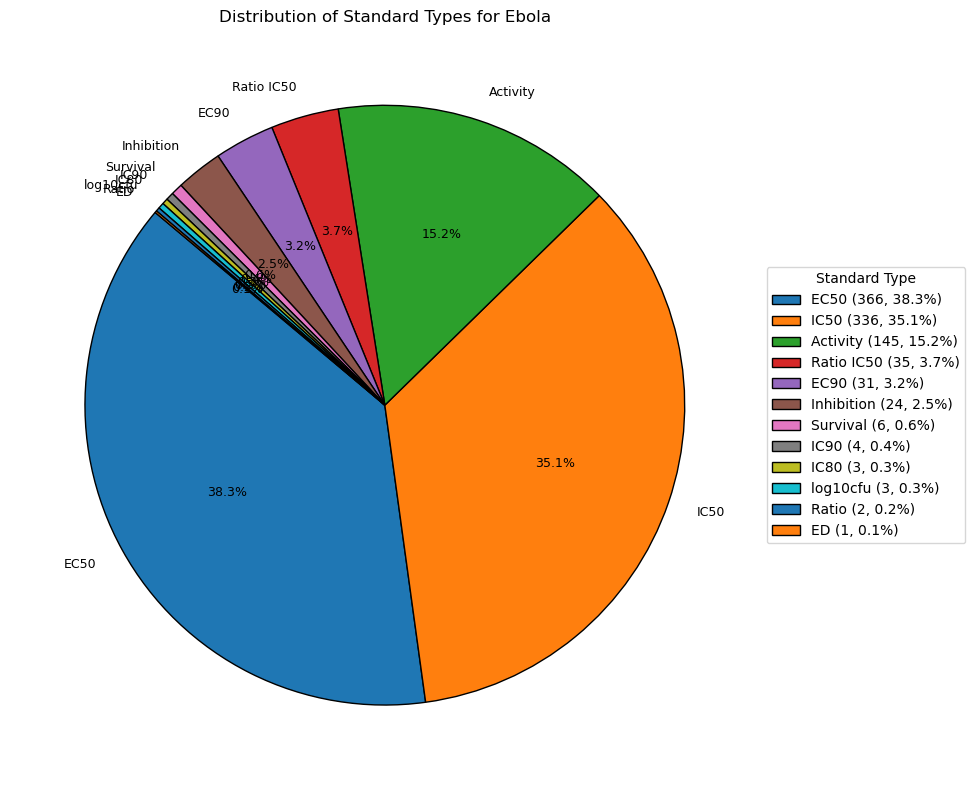


--- Checking for NaN values ---
Smiles                   :      0 (  0.0%)
Standard Value           :     75 (  7.8%)
Standard Units           :    106 ( 11.1%)
Standard Type            :      0 (  0.0%)
Standard Relation        :     75 (  7.8%)
pChEMBL Value            :    347 ( 36.3%)
Molecule ChEMBL ID       :      0 (  0.0%)
Molecular Weight         :      0 (  0.0%)
AlogP                    :      6 (  0.6%)
Target ChEMBL ID         :      0 (  0.0%)
Target Name              :      0 (  0.0%)
Target Organism          :      0 (  0.0%)

Number of unique compounds for Ebola: 582

--- Processing Compounds Data ---
Compounds data shape: (582, 29)
Cleaned compounds data saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/EbolaCompounds_chEMBL_cleaned.csv

--- Combining Bioassay and Compound Data ---
Final combined data saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/EbolaData_chEMBL_combined.csv 

In [4]:
virusName = 'Ebola'  
virusDataDir = os.path.join(dataDir, virusName)
processVirusData(virusName)

# Processing data files for `Marburg` virus


--- Processing Bioassay Data ---
Reading ChEMBL CSV file: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Marburg/Marburg_bioactivity.csv
Dataset loaded successfully with Shape: (227, 48)
Dataset shape after selecting columns: (227, 48) → (227, 12)
Cleaned bioassay data saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/MarburgBioassay_chEMBL_cleaned.csv

--- Analyzing Standard Types ---
Standard types plot saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/Marburg_standard_types.png


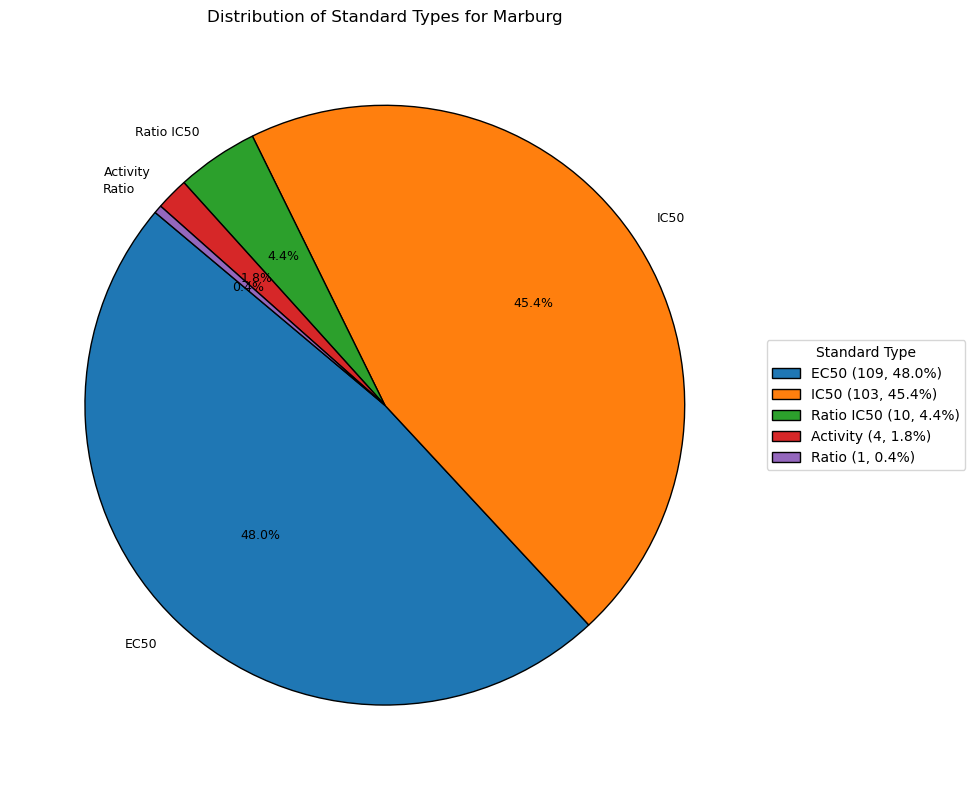


--- Checking for NaN values ---
Smiles                   :      0 (  0.0%)
Standard Value           :     12 (  5.3%)
Standard Units           :     23 ( 10.1%)
Standard Type            :      0 (  0.0%)
Standard Relation        :     12 (  5.3%)
pChEMBL Value            :     48 ( 21.1%)
Molecule ChEMBL ID       :      0 (  0.0%)
Molecular Weight         :      0 (  0.0%)
AlogP                    :      0 (  0.0%)
Target ChEMBL ID         :      0 (  0.0%)
Target Name              :      0 (  0.0%)
Target Organism          :      0 (  0.0%)

Number of unique compounds for Marburg: 170

--- Processing Compounds Data ---
Compounds data shape: (170, 29)
Cleaned compounds data saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/MarburgCompounds_chEMBL_cleaned.csv

--- Combining Bioassay and Compound Data ---
Final combined data saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/MarburgData_chEMBL_combine

In [5]:
virusName = 'Marburg'  
virusDataDir = os.path.join(dataDir, virusName)
processVirusData(virusName)

# Processing data files for `Lassa` virus


--- Processing Bioassay Data ---
Reading ChEMBL CSV file: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Lassa/Lassa_bioactivity.csv
Dataset loaded successfully with Shape: (234, 48)
Dataset shape after selecting columns: (234, 48) → (234, 12)
Cleaned bioassay data saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/LassaBioassay_chEMBL_cleaned.csv

--- Analyzing Standard Types ---
Standard types plot saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/Lassa_standard_types.png


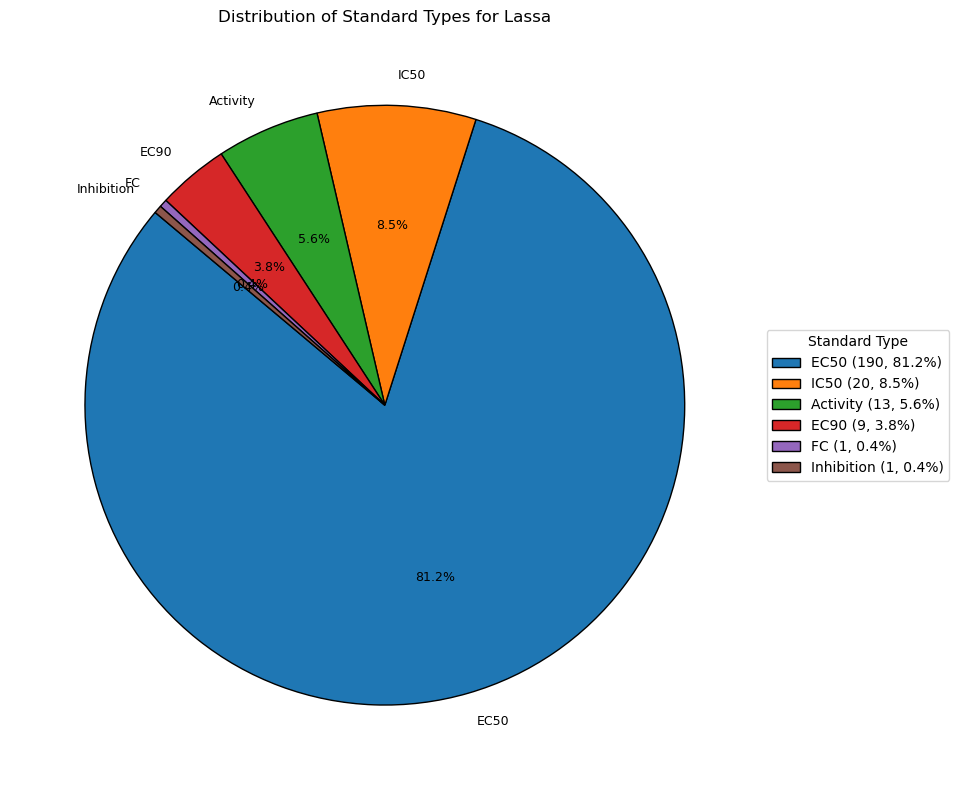


--- Checking for NaN values ---
Smiles                   :      0 (  0.0%)
Standard Value           :     14 (  6.0%)
Standard Units           :     14 (  6.0%)
Standard Type            :      0 (  0.0%)
Standard Relation        :     14 (  6.0%)
pChEMBL Value            :     46 ( 19.7%)
Molecule ChEMBL ID       :      0 (  0.0%)
Molecular Weight         :      0 (  0.0%)
AlogP                    :      0 (  0.0%)
Target ChEMBL ID         :      0 (  0.0%)
Target Name              :      0 (  0.0%)
Target Organism          :      0 (  0.0%)

Number of unique compounds for Lassa: 211

--- Processing Compounds Data ---
Compounds data shape: (211, 29)
Cleaned compounds data saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/LassaCompounds_chEMBL_cleaned.csv

--- Combining Bioassay and Compound Data ---
Final combined data saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/LassaData_chEMBL_combined.csv 

In [6]:
virusName = 'Lassa'  
virusDataDir = os.path.join(dataDir, virusName)
processVirusData(virusName)

# Processing data files for `Nipah` virus


--- Processing Bioassay Data ---
Reading ChEMBL CSV file: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Nipah/Nipah_bioactivity.csv
Dataset loaded successfully with Shape: (21, 48)
Dataset shape after selecting columns: (21, 48) → (21, 12)
Cleaned bioassay data saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/NipahBioassay_chEMBL_cleaned.csv

--- Analyzing Standard Types ---
Standard types plot saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/Nipah_standard_types.png


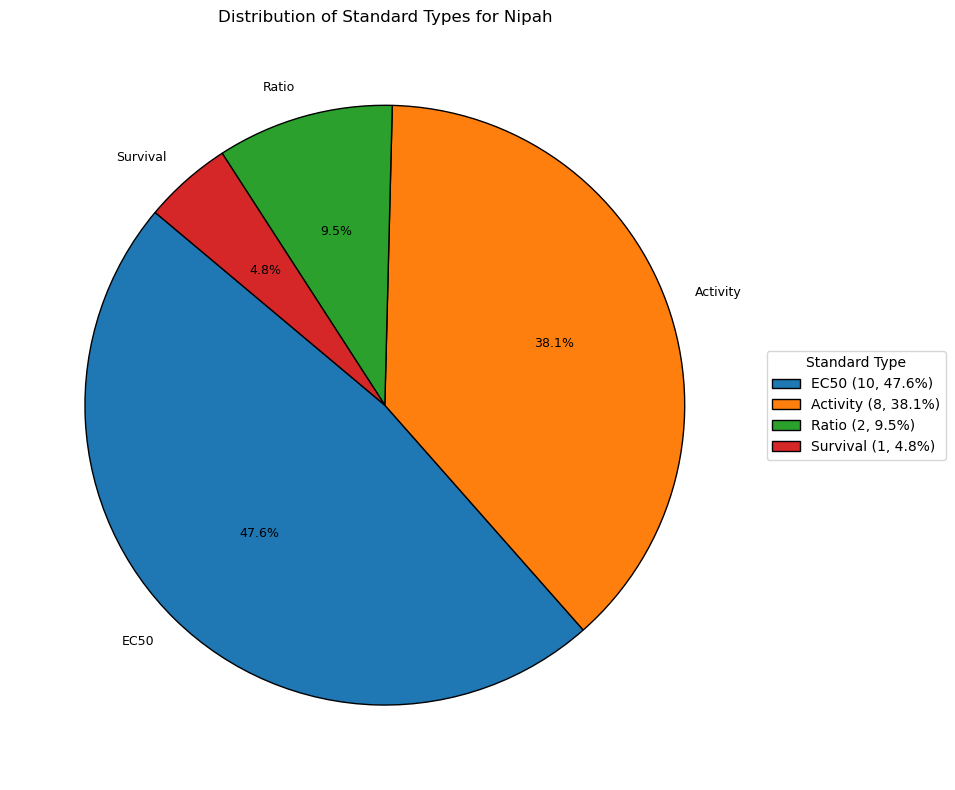


--- Checking for NaN values ---
Smiles                   :      0 (  0.0%)
Standard Value           :      8 ( 38.1%)
Standard Units           :     10 ( 47.6%)
Standard Type            :      0 (  0.0%)
Standard Relation        :      8 ( 38.1%)
pChEMBL Value            :     11 ( 52.4%)
Molecule ChEMBL ID       :      0 (  0.0%)
Molecular Weight         :      0 (  0.0%)
AlogP                    :      0 (  0.0%)
Target ChEMBL ID         :      0 (  0.0%)
Target Name              :      0 (  0.0%)
Target Organism          :      0 (  0.0%)

Number of unique compounds for Nipah: 12

--- Processing Compounds Data ---
Compounds data shape: (12, 29)
Cleaned compounds data saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/NipahCompounds_chEMBL_cleaned.csv

--- Combining Bioassay and Compound Data ---
Final combined data saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/NipahData_chEMBL_combined.csv wi

In [7]:
virusName = 'Nipah'  
virusDataDir = os.path.join(dataDir, virusName)
processVirusData(virusName)

# Processing data files for `Venezuelan equine encephalitis virus (VEEV)`


--- Processing Bioassay Data ---
Reading ChEMBL CSV file: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/VEEV/VEEV_bioactivity.csv
Dataset loaded successfully with Shape: (474, 48)
Dataset shape after selecting columns: (474, 48) → (474, 12)
Cleaned bioassay data saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/VEEVBioassay_chEMBL_cleaned.csv

--- Analyzing Standard Types ---
Standard types plot saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/VEEV_standard_types.png


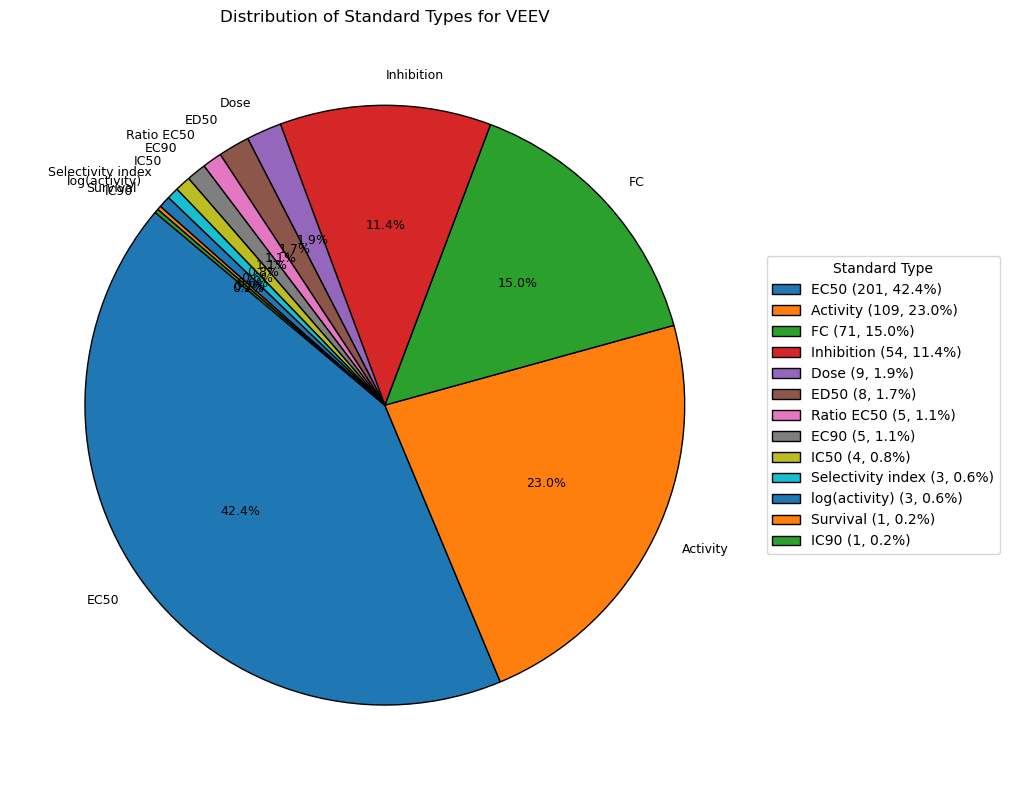


--- Checking for NaN values ---
Smiles                   :      0 (  0.0%)
Standard Value           :    112 ( 23.6%)
Standard Units           :    147 ( 31.0%)
Standard Type            :      0 (  0.0%)
Standard Relation        :    112 ( 23.6%)
pChEMBL Value            :    337 ( 71.1%)
Molecule ChEMBL ID       :      0 (  0.0%)
Molecular Weight         :      0 (  0.0%)
AlogP                    :      1 (  0.2%)
Target ChEMBL ID         :      0 (  0.0%)
Target Name              :      0 (  0.0%)
Target Organism          :      0 (  0.0%)

Number of unique compounds for VEEV: 275

--- Processing Compounds Data ---
Compounds data shape: (275, 29)
Cleaned compounds data saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/VEEVCompounds_chEMBL_cleaned.csv

--- Combining Bioassay and Compound Data ---
Final combined data saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/VEEVData_chEMBL_combined.csv wit

In [8]:
virusName = 'VEEV'  
virusDataDir = os.path.join(dataDir, virusName)
processVirusData(virusName)

# Processing data files for `Hantavirus`


--- Processing Bioassay Data ---
Reading ChEMBL CSV file: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Hanta/Hanta_bioactivity.csv
Dataset loaded successfully with Shape: (157, 48)
Dataset shape after selecting columns: (157, 48) → (157, 12)
Cleaned bioassay data saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/HantaBioassay_chEMBL_cleaned.csv

--- Analyzing Standard Types ---
Standard types plot saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/Hanta_standard_types.png


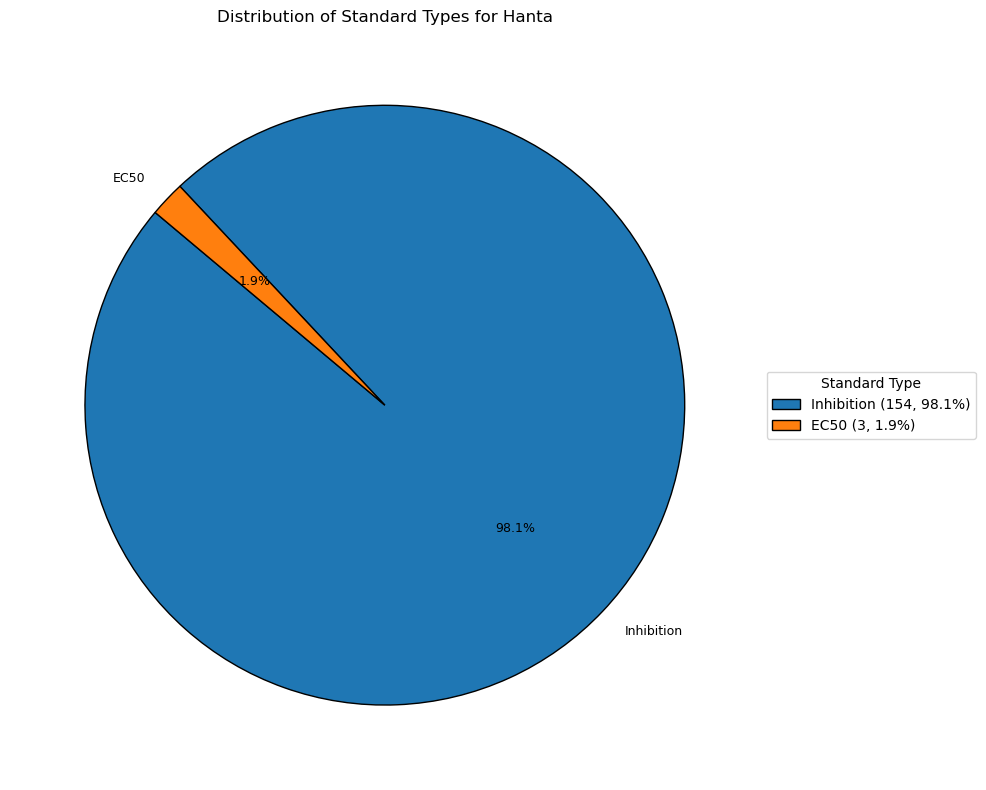


--- Checking for NaN values ---
Smiles                   :      0 (  0.0%)
Standard Value           :     35 ( 22.3%)
Standard Units           :      0 (  0.0%)
Standard Type            :      0 (  0.0%)
Standard Relation        :     35 ( 22.3%)
pChEMBL Value            :    154 ( 98.1%)
Molecule ChEMBL ID       :      0 (  0.0%)
Molecular Weight         :      0 (  0.0%)
AlogP                    :      1 (  0.6%)
Target ChEMBL ID         :      0 (  0.0%)
Target Name              :      0 (  0.0%)
Target Organism          :      0 (  0.0%)

Number of unique compounds for Hanta: 119

--- Processing Compounds Data ---
Compounds data shape: (119, 29)
Cleaned compounds data saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/HantaCompounds_chEMBL_cleaned.csv

--- Combining Bioassay and Compound Data ---
Final combined data saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/HantaData_chEMBL_combined.csv 

In [9]:
virusName = 'Hanta'  
virusDataDir = os.path.join(dataDir, virusName)
processVirusData(virusName)

# Processing data files for `SARS-CoV`


--- Processing Bioassay Data ---
Reading ChEMBL CSV file: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/SARS-CoV/SARS-CoV_bioactivity.csv
Dataset loaded successfully with Shape: (450, 48)
Dataset shape after selecting columns: (450, 48) → (450, 12)
Cleaned bioassay data saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/SARS-CoVBioassay_chEMBL_cleaned.csv

--- Analyzing Standard Types ---
Standard types plot saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/SARS-CoV_standard_types.png


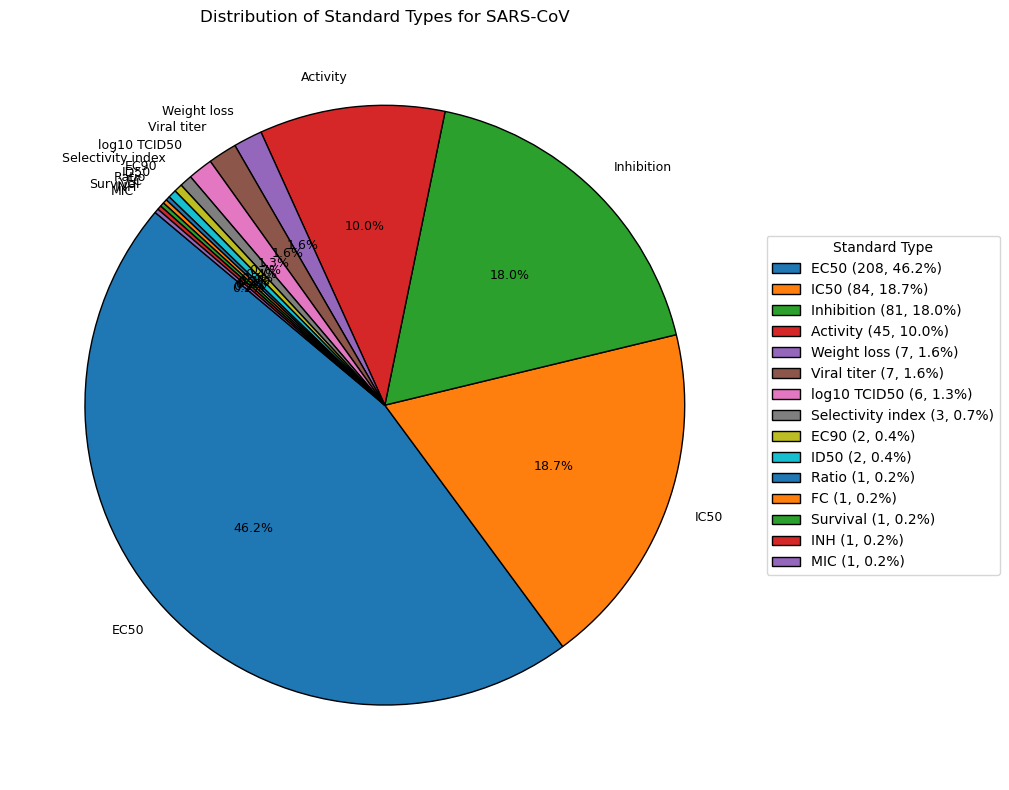


--- Checking for NaN values ---
Smiles                   :      0 (  0.0%)
Standard Value           :     76 ( 16.9%)
Standard Units           :     71 ( 15.8%)
Standard Type            :      0 (  0.0%)
Standard Relation        :     76 ( 16.9%)
pChEMBL Value            :    234 ( 52.0%)
Molecule ChEMBL ID       :      0 (  0.0%)
Molecular Weight         :      0 (  0.0%)
AlogP                    :     14 (  3.1%)
Target ChEMBL ID         :      0 (  0.0%)
Target Name              :      0 (  0.0%)
Target Organism          :      0 (  0.0%)

Number of unique compounds for SARS-CoV: 246

--- Processing Compounds Data ---
Compounds data shape: (79, 29)
Cleaned compounds data saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/SARS-CoVCompounds_chEMBL_cleaned.csv

--- Combining Bioassay and Compound Data ---
Final combined data saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/SARS-CoVData_chEMBL_combi

In [11]:
virusName = 'SARS-CoV'  
virusDataDir = os.path.join(dataDir, virusName)
processVirusData(virusName)

# Processing data files for `SARS-CoV-2`


--- Processing Bioassay Data ---
Reading ChEMBL CSV file: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/SARS-CoV-2/SARS-CoV-2_bioactivity.csv
Dataset loaded successfully with Shape: (40586, 48)
Dataset shape after selecting columns: (40586, 48) → (40586, 12)
Cleaned bioassay data saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/SARS-CoV-2Bioassay_chEMBL_cleaned.csv

--- Analyzing Standard Types ---
Standard types plot saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/SARS-CoV-2_standard_types.png


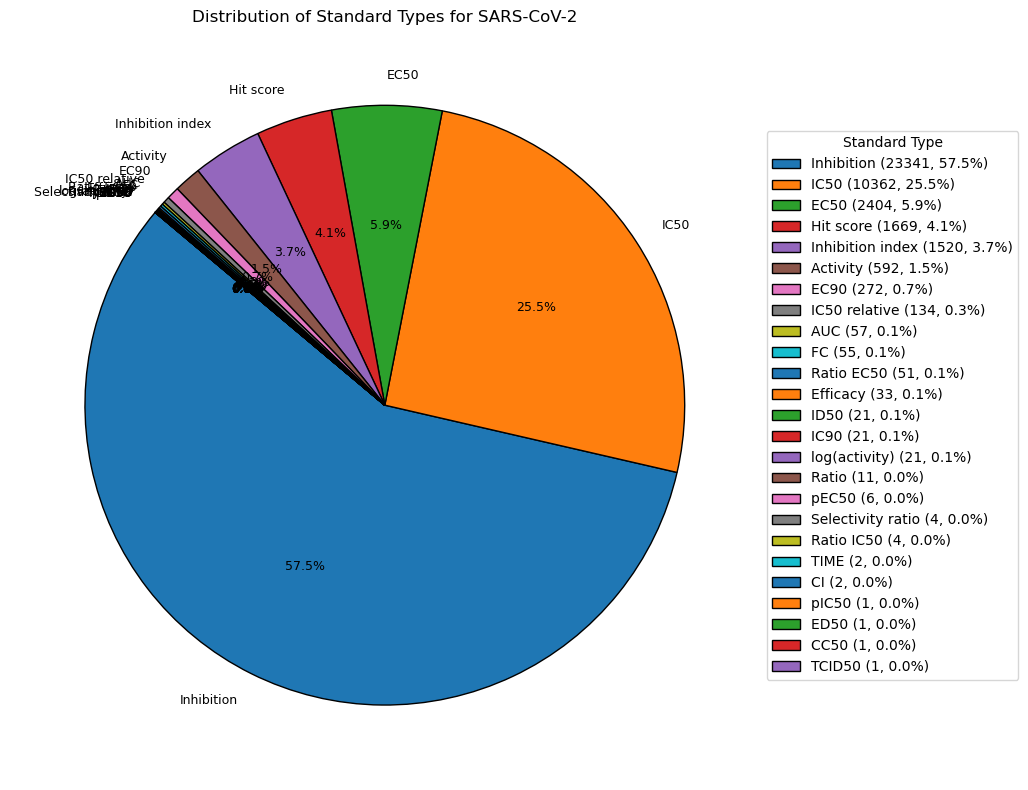


--- Checking for NaN values ---
Smiles                   :    229 (  0.6%)
Standard Value           :    673 (  1.7%)
Standard Units           :  4,048 ( 10.0%)
Standard Type            :      0 (  0.0%)
Standard Relation        :    897 (  2.2%)
pChEMBL Value            : 37,824 ( 93.2%)
Molecule ChEMBL ID       :      0 (  0.0%)
Molecular Weight         :    136 (  0.3%)
AlogP                    :  1,098 (  2.7%)
Target ChEMBL ID         :      0 (  0.0%)
Target Name              :      0 (  0.0%)
Target Organism          :      0 (  0.0%)

Number of unique compounds for SARS-CoV-2: 11952

--- Processing Compounds Data ---
Compounds data shape: (380, 29)
Cleaned compounds data saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/SARS-CoV-2Compounds_chEMBL_cleaned.csv

--- Combining Bioassay and Compound Data ---
Final combined data saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/SARS-CoV-2Data_chE

In [13]:
virusName = 'SARS-CoV-2'  
virusDataDir = os.path.join(dataDir, virusName)
processVirusData(virusName)

### Combine the data set of all the viruses into one large data set

In [15]:
# ===== SPECIFY FILES EXPLICITLY =====
fileList = [
    os.path.join(modelBuildingDataDir, "SARS-CoV-2Data_chEMBL_combined.csv"),
    os.path.join(modelBuildingDataDir, "NipahData_chEMBL_combined.csv"),
    os.path.join(modelBuildingDataDir, "VEEVData_chEMBL_combined.csv"),
    os.path.join(modelBuildingDataDir, "EbolaData_chEMBL_combined.csv"),
    os.path.join(modelBuildingDataDir, "LassaData_chEMBL_combined.csv"),
    os.path.join(modelBuildingDataDir, "SARS-CoVData_chEMBL_combined.csv"),
    os.path.join(modelBuildingDataDir, "MarburgData_chEMBL_combined.csv"),
    os.path.join(modelBuildingDataDir, "HantaData_chEMBL_combined.csv"),
]



# Read and concatenate row-wise
dfList = []
for file in fileList:
    if os.path.exists(file):
        df = pd.read_csv(file)
        # Extract virus name from filename
        virus_name = os.path.basename(file).replace("Data_chEMBL_combined.csv", "")
        df["Virus"] = virus_name
        
        print(f" Loaded {os.path.basename(file):40s} → Shape: {df.shape}")
        dfList.append(df)
    else:
        print(f" File not found: {os.path.basename(file)}")

# Concatenate all
if dfList:
    allVirusData_chEMBL = pd.concat(dfList, ignore_index=True)
    print(f"Final combined shape: {allVirusData_chEMBL.shape}")
    
    # Save the combined dataframe
    outFile = os.path.join(modelBuildingDataDir, "AllVirusData_chEMBL_combined.csv")
    allVirusData_chEMBL.to_csv(outFile, index=False)
    print(f"\n Saved merged CSV to: {outFile}")
else:
    print("\n ERROR: No files were loaded!")

 Loaded SARS-CoV-2Data_chEMBL_combined.csv       → Shape: (40586, 25)
 Loaded NipahData_chEMBL_combined.csv            → Shape: (21, 25)
 Loaded VEEVData_chEMBL_combined.csv             → Shape: (474, 25)
 Loaded EbolaData_chEMBL_combined.csv            → Shape: (956, 25)
 Loaded LassaData_chEMBL_combined.csv            → Shape: (234, 25)
 Loaded SARS-CoVData_chEMBL_combined.csv         → Shape: (450, 25)
 Loaded MarburgData_chEMBL_combined.csv          → Shape: (227, 25)
 Loaded HantaData_chEMBL_combined.csv            → Shape: (157, 25)
Final combined shape: (43105, 25)

 Saved merged CSV to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/AllVirusData_chEMBL_combined.csv


### Extract the strain bioactivity data for `Ebola` virus

In [4]:
dataDir = '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/chEMBL'
modelBuildingDataDir = os.path.join(dataDir, 'modelBuildingData')
ebola_allStrain_chEMBL = readChemblCsvFile(dataDir + "/Ebola/Ebola_bioactivity.csv")
ebola_allStrain_chEMBL

Reading ChEMBL CSV file: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/chEMBL/Ebola/Ebola_bioactivity.csv


,Molecule ChEMBL ID,Molecule Name,Molecule Max Phase,Molecular Weight,#RO5 Violations,AlogP,Compound Key,Smiles,Standard Type,Standard Relation,...,Document ChEMBL ID,Source ID,Source Description,Document Journal,Document Year,Cell ChEMBL ID,Properties,Action Type,Standard Text Value,Value
0,CHEMBL4065616,REMDESIVIR,4.0,602.59,2.0,2.31,4b,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,Activity,'<',...,CHEMBL4007399,1,Scientific Literature,J Med Chem,2017,NaN,NaN,NaN,NaN,80000.00
1,CHEMBL4065616,REMDESIVIR,4.0,602.59,2.0,2.31,4b,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,Activity,NaN,...,CHEMBL4007399,1,Scientific Literature,J Med Chem,2017,NaN,NaN,NaN,NaN,NaN
2,CHEMBL3596788,NaN,NaN,265.27,0.0,-0.10,1,COc1nc(N)ncc1-c1cn(COCCO)cn1,EC50,'>',...,CHEMBL4020744,1,Scientific Literature,Bioorg Med Chem Lett,2017,CHEMBL3308376,NaN,NaN,NaN,100.00
3,CHEMBL4080961,NaN,NaN,232.24,0.0,-0.15,1; DHCDA,Nc1nccc2c1ncn2[C@H]1C=C[C@H](O)[C@@H]1O,EC50,'=',...,CHEMBL4043174,1,Scientific Literature,Bioorg Med Chem Lett,2017,NaN,NaN,NaN,NaN,29.50
4,CHEMBL4081268,NaN,NaN,325.17,0.0,0.69,4,Nc1ncc(Br)c2c1ncn2[C@@H]1[C@@H](O)[C@@H](O)[C@...,Activity,NaN,...,CHEMBL4043174,1,Scientific Literature,Bioorg Med Chem Lett,2017,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
951,CHEMBL5591747,NaN,NaN,336.52,0.0,3.16,7c,CCN1CCN(CCCC(=O)O[C@H]2C(C)(C)[C@H]3CC[C@]2(C)...,IC50,'=',...,CHEMBL5579834,1,Scientific Literature,Eur J Med Chem,2024,NaN,TIME = 49.0 hr,NaN,NaN,5.30
952,CHEMBL5592622,NaN,NaN,294.44,0.0,1.85,12a,C[C@@H]1[C@H]2C[C@@H](C[C@H]1OC(=O)CN1CCN(C)CC...,IC50,'>',...,CHEMBL5579834,1,Scientific Literature,Eur J Med Chem,2024,NaN,TIME = 49.0 hr,NaN,NaN,34.00
953,CHEMBL221722,FAVIPIRAVIR,4.0,157.10,0.0,-0.58,T-705; 2,NC(=O)c1nc(F)cnc1O,EC50,'=',...,CHEMBL5537108,1,Scientific Literature,Eur J Med Chem,2023,NaN,TIME = 72.0 hr,NaN,NaN,61.88
954,CHEMBL5595942,NaN,NaN,295.42,0.0,2.47,3b,CC1(C)[C@H]2CC[C@](C)(C2)[C@H]1OC(=O)CCN1CCOCC1,IC50,'>',...,CHEMBL5579834,1,Scientific Literature,Eur J Med Chem,2024,NaN,TIME = 49.0 hr,NaN,NaN,34.00


### Extract all columns names

In [5]:
print(ebola_allStrain_chEMBL.columns.tolist())

['Molecule ChEMBL ID', 'Molecule Name', 'Molecule Max Phase', 'Molecular Weight', '#RO5 Violations', 'AlogP', 'Compound Key', 'Smiles', 'Standard Type', 'Standard Relation', 'Standard Value', 'Standard Units', 'pChEMBL Value', 'Data Validity Comment', 'Comment', 'Uo Units', 'Ligand Efficiency BEI', 'Ligand Efficiency LE', 'Ligand Efficiency LLE', 'Ligand Efficiency SEI', 'Potential Duplicate', 'Assay ChEMBL ID', 'Assay Description', 'Assay Type', 'BAO Format ID', 'BAO Label', 'Assay Organism', 'Assay Tissue ChEMBL ID', 'Assay Tissue Name', 'Assay Cell Type', 'Assay Subcellular Fraction', 'Assay Parameters', 'Assay Variant Accession', 'Assay Variant Mutation', 'Target ChEMBL ID', 'Target Name', 'Target Organism', 'Target Type', 'Document ChEMBL ID', 'Source ID', 'Source Description', 'Document Journal', 'Document Year', 'Cell ChEMBL ID', 'Properties', 'Action Type', 'Standard Text Value', 'Value']


In [6]:
print(ebola_allStrain_chEMBL['Target Name'].unique())

['Ebolavirus']


In [11]:
print(ebola_allStrain_chEMBL['Assay Cell Type'].unique())

[nan 'HeLa' 'HepG2' 'Huh-7' 'Jurkat' 'Vero' 'Vero C1008' 'A549' 'COS-1'
 'HEK293T' 'Vero E6' 'Macrophage' 'Epithelial cell' 'Primary macrophage'
 'HEK-293T' 'Vero 76' 'MDM' 'U2OS' '293TA' 'HFF']


In [15]:
import requests

baseUrl = 'https://admetlab3.scbdd.com'

if __name__ == '__main__':
    api = '/api/admet'
    url = baseUrl + api
    param = {
        'SMILES': ["COCCN1C(=NC2=C1C(=O)NC(=O)N2C)N(C)CC=3C=CC=CC3", "CC(C)OC(=O)CC(=O)CSc1nc2c(cc1C#N)CCC2"],
    }
    response = requests.post(url, json=param)
    if response.status_code == 200:
        data = response.json()['data']
        print(data)

# Extract Data for all species of `Ebola` virus

In [100]:
def readChemblCsvFile(filePath):
    """
    Read ChEMBL CSV file with proper handling of semicolon delimiter and quotes.
    """
    print(f"Reading ChEMBL CSV file: {filePath}")
    if not os.path.exists(filePath):
        print(f"Error: File not found at {filePath}")
        return None
    try:
        dataFrame = pd.read_csv(
            filePath,
            sep=';',
            quotechar='"',
            quoting=csv.QUOTE_ALL,
            doublequote=True,
            skipinitialspace=True,
            on_bad_lines='skip',
            encoding='utf-8',
            low_memory=False
        )
        return dataFrame
    except Exception as e:
        print(f"Standard pandas method failed: {e}")
        return None

def splitSemicolonRobust(line: str):
    """
    Robustly splits a line by semicolons, handling quotes.
    """
    fields, cur = [], []
    inQuote = False
    i = 0
    while i < len(line):
        ch = line[i]
        if ch == '"':
            if inQuote and i + 1 < len(line) and line[i+1] == '"':
                cur.append('"')
                i += 2
                continue
            inQuote = not inQuote
            i += 1
            continue
        if ch == ';' and not inQuote:
            fields.append(''.join(cur))
            cur = []
            i += 1
            continue
        cur.append(ch)
        i += 1
    fields.append(''.join(cur))
    return fields

def processVirusData(virusDataDir, modelBuildingDataDir, virusName='Ebola'):
    """
    Main function to process bioactivity and compound data for all Ebola virus strains.
    Merges all strains into single CSV files.
    """
    
    if not os.path.exists(virusDataDir):
        print(f"Error: Data directory not found at {virusDataDir}")
        return
    
    if not os.path.exists(modelBuildingDataDir):
        os.makedirs(modelBuildingDataDir)
        print(f"Created output directory: {modelBuildingDataDir}")
    
    # Define all Ebola strains to process
    strains = ['Ebola', 'BundibugyoEbola', 'SudanEbola', 'TaiForestEbola', 'ZaireEbola']
    
    print(f"\n{'-'*80}")
    print(f"Processing {len(strains)} Ebola strain(s)")
    print(f"{'-'*80}\n")
    
    # Store cleaned bioassay data for all strains
    all_bioassay_data = []
    all_compounds_data = []
    all_combined_data = []
    
    # Selected columns for bioassay data
    selectedColumns = ['Smiles', 'Standard Value', 'Standard Units', 'Standard Type',
                      'Standard Relation', 'pChEMBL Value', 'Molecule ChEMBL ID',
                      'Molecular Weight', 'AlogP', 'Target ChEMBL ID',
                      'Target Name', 'Target Organism']
    
    # Process each strain
    for strain in strains:
        print(f"\n{'-'*80}")
        print(f"Processing strain: {strain}")
        print(f"{'-'*80}")
        
        # ### ChEMBL Bioassay Data
        print("\n--- Processing Bioassay Data ---")
        bioactivityFile = os.path.join(virusDataDir, f'{strain}_bioactivity.csv')
        
        if not os.path.exists(bioactivityFile):
            print(f"Warning: Bioactivity file not found for {strain}, skipping...")
            continue
            
        chemblData = readChemblCsvFile(bioactivityFile)
        
        if chemblData is None:
            print(f"Warning: Could not read bioactivity data for {strain}, skipping...")
            continue
        
        print(f"Dataset loaded successfully with Shape: {chemblData.shape}")
        
        # Keep only relevant properties
        chemblDataCleaned = chemblData[[col for col in selectedColumns if col in chemblData.columns]].copy()
        print(f"Dataset shape after selecting columns: {chemblData.shape} → {chemblDataCleaned.shape}")
        
        # Add strain identifier column
        chemblDataCleaned['Strain'] = strain
        
        # Append to list for merging
        all_bioassay_data.append(chemblDataCleaned)
        
        # ### Count unique compounds
        if "Molecule ChEMBL ID" in chemblDataCleaned.columns:
            uniqueCount = chemblDataCleaned["Molecule ChEMBL ID"].nunique()
            print(f"Number of unique compounds for {strain}: {uniqueCount}")
        
        # ### ChEMBL compounds data
        print("\n--- Processing Compounds Data ---")
        compoundsFile = os.path.join(virusDataDir, f'{strain}_compounds.csv')
        
        if not os.path.exists(compoundsFile):
            print(f"Warning: Compounds file not found for {strain}")
            continue
        
        try:
            with open(compoundsFile, "r", encoding="utf-8", errors="replace") as f:
                rawLines = [ln.rstrip("\n") for ln in f]
            
            header = splitSemicolonRobust(rawLines[0])
            ncols = len(header)
            rows = [header]
            buffer = ""
            for line in rawLines[1:]:
                buffer = f"{buffer}\n{line}" if buffer else line
                parsed = splitSemicolonRobust(buffer)
                if len(parsed) == ncols:
                    rows.append(parsed)
                    buffer = ""
            if buffer:
                parsed = splitSemicolonRobust(buffer)
                parsed += [""] * (ncols - len(parsed)) if len(parsed) < ncols else []
                rows.append(parsed[:ncols])
            
            chemblCompoundData = pd.DataFrame(rows[1:], columns=header)
            chemblCompoundData.columns = [re.sub(r"[^\w]+", "_", c).strip("_").lower() for c in chemblCompoundData.columns]
            
            # Standardize the ChEMBL ID column name for merging
            if 'molecule_chembl_id' in chemblCompoundData.columns:
                chemblCompoundData = chemblCompoundData.rename(columns={'molecule_chembl_id': 'chembl_id'})
            
            numCols = ["molecular_weight", "alogp", "polar_surface_area", "hba", "hbd", "ro5_violations", 
                      "rotatable_bonds", "qed_weighted", "heavy_atoms"]
            for c in numCols:
                if c in chemblCompoundData.columns:
                    chemblCompoundData[c] = pd.to_numeric(chemblCompoundData[c], errors="coerce")
            
            # Add strain identifier
            chemblCompoundData['strain'] = strain
            
            print(f"Compounds data shape: {chemblCompoundData.shape}")
            all_compounds_data.append(chemblCompoundData)
            
        except Exception as e:
            print(f"Error processing compounds data for {strain}: {e}")
            continue
    
    # ### Merge all bioassay data
    if all_bioassay_data:
        
        merged_bioassay = pd.concat(all_bioassay_data, ignore_index=True)
        print(f"Merged bioassay data shape: {merged_bioassay.shape}")
        
        # Print distribution by strain
        print("\nRecords per strain:")
        for strain, count in merged_bioassay['Strain'].value_counts().items():
            print(f"  {strain}: {count:,}")
        
        # Save merged bioassay data
        bioassay_output = os.path.join(modelBuildingDataDir, 'EbolaBioassay_chEMBL_cleaned_allStrains.csv')
        merged_bioassay.to_csv(bioassay_output, index=False)
        print(f"\nMerged bioassay data saved to: {bioassay_output}")
    else:
        print("\nNo bioassay data was successfully processed.")
        return
    
    # ### Merge all compounds data
    if all_compounds_data:
        
        merged_compounds = pd.concat(all_compounds_data, ignore_index=True)
        print(f"Merged compounds data shape: {merged_compounds.shape}")
        
        # Print distribution by strain
        print("\nCompound records per strain:")
        for strain, count in merged_compounds['strain'].value_counts().items():
            print(f"  {strain}: {count:,}")
        
        # Save merged compounds data
        compounds_output = os.path.join(modelBuildingDataDir, 'EbolaCompounds_chEMBL_cleaned_allStrains.csv')
        merged_compounds.to_csv(compounds_output, index=False)
        print(f"\nMerged compounds data saved to: {compounds_output}")
        
        # ### Combine bioassay and compound data
        
        colsToImport = ['chembl_id', 'type', 'polar_surface_area', 'hba', 'hbd', 'rotatable_bonds', 
                       'qed_weighted', 'heavy_atoms', 'aromatic_rings', 'ro5_violations', 
                       'molecular_formula', 'inchi_key', 'inchi', 'strain']
        cmpdSub = merged_compounds.loc[:, [c for c in colsToImport if c in merged_compounds.columns]].copy()
        
        chemblDataCombined = merged_bioassay.merge(
            cmpdSub, how='left', left_on='Molecule ChEMBL ID', right_on='chembl_id', suffixes=('', '_cmp')
        )
        if 'chembl_id' in chemblDataCombined.columns:
            chemblDataCombined = chemblDataCombined.drop(columns=['chembl_id'])
        
        # Handle duplicate strain columns
        if 'strain' in chemblDataCombined.columns and 'Strain' in chemblDataCombined.columns:
            chemblDataCombined = chemblDataCombined.drop(columns=['strain'])
        
        # Rename columns to lowercase
        chemblDataCombined = chemblDataCombined.rename(columns={
            "Smiles": "smiles", "Standard Value": "standard_value", "Standard Units": "standard_units",
            "Standard Type": "standard_type", "Standard Relation": "standard_relation", 
            "pChEMBL Value": "pchembl_value", "Molecule ChEMBL ID": "molecule_chembl_id", 
            "Molecular Weight": "molecular_weight", "Strain": "strain"
        })
        
        # Reorder columns
        desiredOrder = [
            "strain", "molecule_chembl_id", "smiles", "molecular_formula", "inchi_key", "inchi", 
            "molecular_weight", "type", "standard_value", "standard_units", "standard_relation", 
            "standard_type", "pchembl_value", "AlogP", "polar_surface_area", "hba", "hbd", 
            "rotatable_bonds", "qed_weighted", "heavy_atoms", "aromatic_rings", "ro5_violations", 
            "Target ChEMBL ID", "Target Name", "Target Organism"
        ]
        
        existing = [c for c in desiredOrder if c in chemblDataCombined.columns]
        extras = [c for c in chemblDataCombined.columns if c not in existing]
        newColOrder = existing + extras
        
        chemblDataCombined = chemblDataCombined[newColOrder]
        
        combined_output = os.path.join(modelBuildingDataDir, 'EbolaData_chEMBL_combined_allStrains.csv')
        chemblDataCombined.to_csv(combined_output, index=False)
        print(f"Final combined data saved to: {combined_output} with shape {chemblDataCombined.shape}")
    
    # Strain distribution plot
    plt.figure(figsize=(12, 6))
    strain_counts = merged_bioassay['Strain'].value_counts()
    strain_counts.plot(kind='bar', color='steelblue', edgecolor='black')
    plt.title('Number of Bioassay Records per Ebola Strain', fontsize=14, fontweight='bold')
    plt.xlabel('Strain', fontsize=12)
    plt.ylabel('Number of Records', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plot_path = os.path.join(modelBuildingDataDir, 'Ebola_strains_distribution.png')
    plt.savefig(plot_path, dpi=300)
    print(f"Strain distribution plot saved to: {plot_path}")
    plt.show()
    
    # Standard Type distribution across all strains
    if 'standard_type' in chemblDataCombined.columns:
        plt.figure(figsize=(10, 8))
        typeCounts = chemblDataCombined["standard_type"].value_counts()
        total = typeCounts.sum()
        legendLabels = [f"{stype} ({count}, {count/total:.1%})" for stype, count in typeCounts.items()]
        
        wedges, texts, autotexts = plt.pie(
            typeCounts, labels=typeCounts.index, autopct='%1.1f%%',
            startangle=140, wedgeprops={'edgecolor': 'black'}, textprops={'fontsize': 9}
        )
        plt.legend(wedges, legendLabels, title="Standard Type", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
        plt.title("Distribution of Standard Types for All Ebola Strains")
        plt.tight_layout()
        plotPath = os.path.join(modelBuildingDataDir, 'Ebola_allStrains_standard_types.png')
        plt.savefig(plotPath, dpi=300)
        print(f"Standard types plot saved to: {plotPath}")
        plt.show()
    
    
    print(f"\nOutput files:")
    print(f"  1. EbolaBioassay_chEMBL_cleaned_allStrains.csv")
    print(f"  2. EbolaCompounds_chEMBL_cleaned_allStrains.csv")
    print(f"  3. EbolaData_chEMBL_combined_allStrains.csv")
    
    return chemblDataCombined



--------------------------------------------------------------------------------
Processing 5 Ebola strain(s)
--------------------------------------------------------------------------------


--------------------------------------------------------------------------------
Processing strain: Ebola
--------------------------------------------------------------------------------

--- Processing Bioassay Data ---
Reading ChEMBL CSV file: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/chEMBL/Ebola/Ebola_bioactivity.csv
Dataset loaded successfully with Shape: (956, 48)
Dataset shape after selecting columns: (956, 48) → (956, 12)
Number of unique compounds for Ebola: 582

--- Processing Compounds Data ---
Compounds data shape: (582, 30)

--------------------------------------------------------------------------------
Processing strain: BundibugyoEbola
--------------------------------------------------------------------------------

--- Processing Bioassay Data ---
Reading

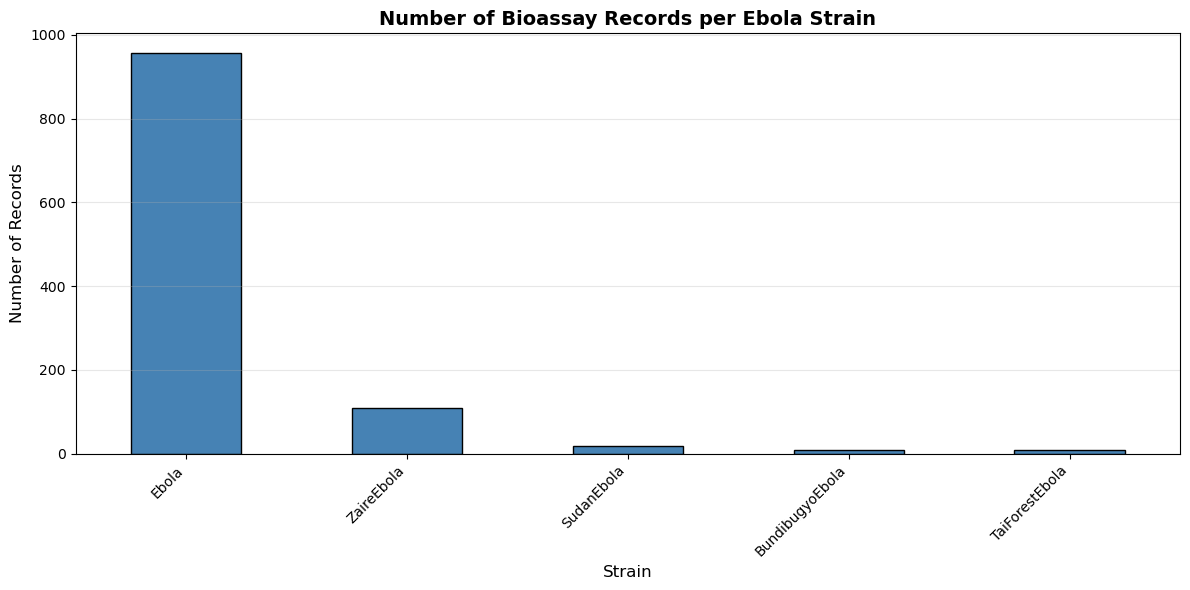

Standard types plot saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/Ebola_allStrains_standard_types.png


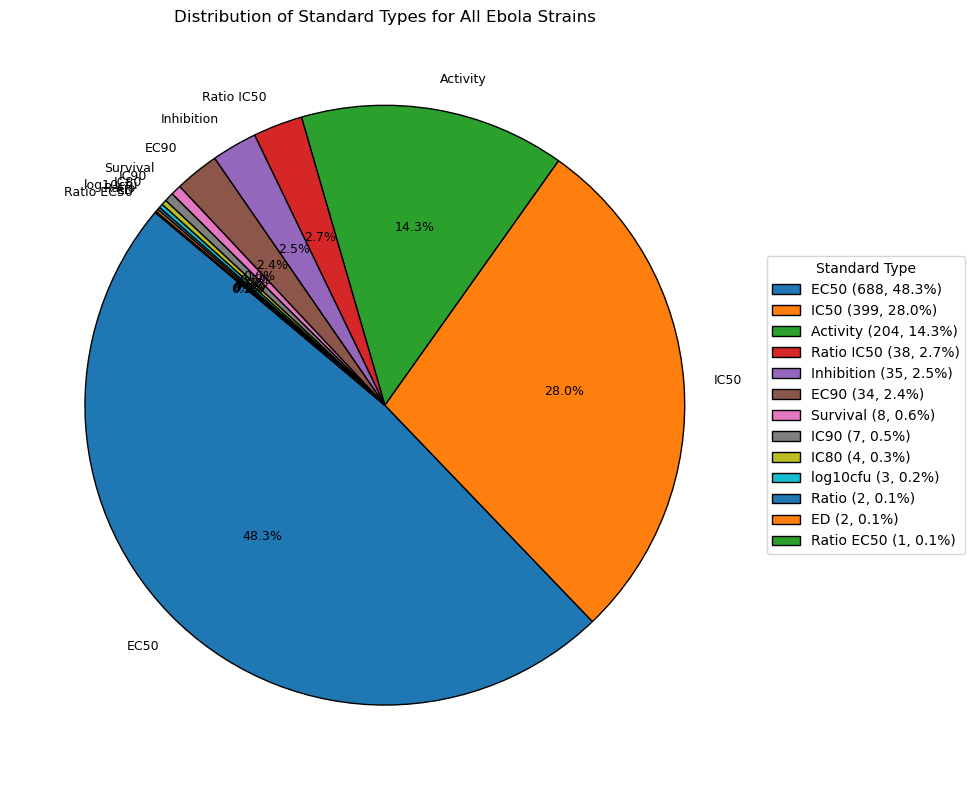


Output files:
  1. EbolaBioassay_chEMBL_cleaned_allStrains.csv
  2. EbolaCompounds_chEMBL_cleaned_allStrains.csv
  3. EbolaData_chEMBL_combined_allStrains.csv


,strain,molecule_chembl_id,smiles,molecular_formula,inchi_key,inchi,molecular_weight,type,standard_value,standard_units,...,hba,hbd,rotatable_bonds,qed_weighted,heavy_atoms,aromatic_rings,ro5_violations,Target ChEMBL ID,Target Name,Target Organism
0,Ebola,CHEMBL4065616,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,C27H35N6O8P,RWWYLEGWBNMMLJ-YSOARWBDSA-N,InChI=1S/C27H35N6O8P/c1-4-18(5-2)13-38-26(36)1...,602.59,Small molecule,80000.0,/ml,...,13.0,4.0,13.0,0.16,42.0,3,2.0,CHEMBL4434621,Ebolavirus,Ebolavirus
1,Ebola,CHEMBL4065616,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,C27H35N6O8P,RWWYLEGWBNMMLJ-YSOARWBDSA-N,InChI=1S/C27H35N6O8P/c1-4-18(5-2)13-38-26(36)1...,602.59,Small molecule,NaN,NaN,...,13.0,4.0,13.0,0.16,42.0,3,2.0,CHEMBL4434621,Ebolavirus,Ebolavirus
2,Ebola,CHEMBL3596788,COc1nc(N)ncc1-c1cn(COCCO)cn1,C11H15N5O3,CVSSXRUFNBCRPB-UHFFFAOYSA-N,InChI=1S/C11H15N5O3/c1-18-10-8(4-13-11(12)15-1...,265.27,Small molecule,100000.0,nM,...,8.0,2.0,6.0,0.70,19.0,2,0.0,CHEMBL4434621,Ebolavirus,Ebolavirus
3,Ebola,CHEMBL4080961,Nc1nccc2c1ncn2[C@H]1C=C[C@H](O)[C@@H]1O,C11H12N4O2,UJJIREDPTVPNLW-OYNCUSHFSA-N,InChI=1S/C11H12N4O2/c12-11-9-6(3-4-13-11)15(5-...,232.24,Small molecule,29.5,ug.mL-1,...,6.0,3.0,1.0,0.59,17.0,2,0.0,CHEMBL4434621,Ebolavirus,Ebolavirus
4,Ebola,CHEMBL4081268,Nc1ncc(Br)c2c1ncn2[C@@H]1[C@@H](O)[C@@H](O)[C@...,C12H13BrN4O2,XJUUPHWULCINAO-MZFBDAEWSA-N,InChI=1S/C12H13BrN4O2/c13-6-2-15-12(14)7-9(6)1...,325.17,Small molecule,NaN,NaN,...,6.0,3.0,1.0,0.72,19.0,2,0.0,CHEMBL4434621,Ebolavirus,Ebolavirus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1420,ZaireEbola,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,C29H34N4O,IJMIYPOMQDWUPR-UHFFFAOYSA-N,InChI=1S/C29H34N4O/c34-29(31-33-27-12-6-4-10-2...,454.62,,520.0,nM,...,4.0,2.0,9.0,0.34,34.0,4,1.0,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus
1421,ZaireEbola,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,C29H34N4O,IJMIYPOMQDWUPR-UHFFFAOYSA-N,InChI=1S/C29H34N4O/c34-29(31-33-27-12-6-4-10-2...,454.62,,520.0,nM,...,4.0,2.0,9.0,0.34,34.0,4,1.0,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus
1422,ZaireEbola,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,C28H34N4O,ARYIHVDLZUTPHU-UHFFFAOYSA-N,InChI=1S/C28H34N4O/c33-28(30-32(26-12-6-2-7-13...,442.61,,1900.0,nM,...,4.0,2.0,10.0,0.35,33.0,3,0.0,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus
1423,ZaireEbola,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,C28H34N4O,ARYIHVDLZUTPHU-UHFFFAOYSA-N,InChI=1S/C28H34N4O/c33-28(30-32(26-12-6-2-7-13...,442.61,,1900.0,nM,...,4.0,2.0,10.0,0.35,33.0,3,0.0,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus


In [101]:
virusName = 'Ebola'  
virusDataDir = os.path.join(dataDir, 'chEMBL/' + virusName)
processVirusData(virusDataDir, modelBuildingDataDir, virusName='Ebola')

# Extract Data from Pubchem Database

In [12]:
import io
import time
import random
from typing import Dict, List, Optional

import requests
import pandas as pd


def requestWithRetry(
    url: str,
    params: Optional[dict] = None,
    timeoutSec: int = 60,
    maxRetries: int = 8,
    baseSleepSec: float = 0.5,
    userAgent: str = "virus-bioassay-harvester/1.0 (email: your_email@domain)"
) -> requests.Response:
    """
    GET with exponential backoff. PubChem can throttle and return HTTP 503. :contentReference[oaicite:3]{index=3}
    """
    headers = {"User-Agent": userAgent}
    lastErr = None

    for attempt in range(maxRetries):
        try:
            resp = requests.get(url, params=params, headers=headers, timeout=timeoutSec)

            if resp.status_code == 503:
                sleepSec = (2 ** attempt) * baseSleepSec + random.random()
                time.sleep(sleepSec)
                continue

            resp.raise_for_status()
            time.sleep(0.2)  # polite pacing
            return resp

        except Exception as e:
            lastErr = e
            sleepSec = (2 ** attempt) * baseSleepSec + random.random()
            time.sleep(sleepSec)

    raise RuntimeError(f"Request failed after retries. url={url} lastErr={lastErr}")


def esearchPcAssayAids(
    term: str,
    retmax: int = 200,
    toolName: str = "virusBioassayHarvester",
    email: str = "your_email@domain",
    apiKey: Optional[str] = None
) -> List[int]:
    """
    Find PubChem BioAssay IDs (AIDs) via NCBI ESearch:
    Base: https://eutils.ncbi.nlm.nih.gov/entrez/eutils/ :contentReference[oaicite:4]{index=4}
    Use tool/email (and optionally api_key) per E-utilities guidelines. :contentReference[oaicite:5]{index=5}
    """
    url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi"
    params = {
        "db": "pcassay",
        "term": term,
        "retmax": retmax,
        "retmode": "json",
        "tool": toolName,
        "email": email,
    }
    if apiKey:
        params["api_key"] = apiKey

    resp = requestWithRetry(url, params=params)
    data = resp.json()
    idList = data.get("esearchresult", {}).get("idlist", [])
    return [int(x) for x in idList]


def fetchConciseAssayCsv(aid: int) -> pd.DataFrame:
    """
    PubChem PUG-REST concise table for one assay:
    https://pubchem.ncbi.nlm.nih.gov/rest/pug/assay/aid/<AID>/concise/CSV :contentReference[oaicite:6]{index=6}
    """
    url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/assay/aid/{aid}/concise/CSV"
    resp = requestWithRetry(url)
    DF = pd.read_csv(io.StringIO(resp.text))
    DF["AID"] = aid
    return DF


def buildAllVirusPubchem(
    virusQueryMap: Dict[str, str],
    aidsPerVirus: int = 200,
    onlyActive: bool = False,
    toolName: str = "virusBioassayHarvester",
    email: str = "your_email@domain",
    apiKey: Optional[str] = None
) -> pd.DataFrame:
    rows = []

    for virusName, entrezTerm in virusQueryMap.items():
        aids = esearchPcAssayAids(
            term=entrezTerm,
            retmax=aidsPerVirus,
            toolName=toolName,
            email=email,
            apiKey=apiKey
        )

        for aid in aids:
            try:
                DF = fetchConciseAssayCsv(aid)
                DF["Virus"] = virusName
                DF["EntrezTerm"] = entrezTerm
                rows.append(DF)
            except Exception:
                # Skip failures; they are often caused by very large or unusual assays
                continue

    if not rows:
        return pd.DataFrame()

    DF = pd.concat(rows, ignore_index=True)

    # Optional filter: keep only rows with an "Active" outcome if the column exists
    if onlyActive:
        outcomeColCandidates = [c for c in DF.columns if c.strip().lower() in ["activityoutcome", "outcome"]]
        if outcomeColCandidates:
            outcomeCol = outcomeColCandidates[0]
            DF = DF[DF[outcomeCol].astype(str).str.lower().eq("active")].copy()

    # User-requested name
    allVirus_pubchem = DF
    return allVirus_pubchem


# ---------------------------
# Customize your virus terms
# ---------------------------
virusQueryMap = {
    "Ebola": '(Ebola OR Ebolavirus OR "Zaire ebolavirus") AND (antiviral OR inhibitor OR neutralization OR IC50 OR EC50)',
    "Marburg": '(Marburg OR Marburgvirus) AND (antiviral OR inhibitor OR neutralization OR IC50 OR EC50)',
    "Lassa": '(Lassa OR "Lassa virus") AND (antiviral OR inhibitor OR neutralization OR IC50 OR EC50)',
    "VEEV": '("Venezuelan equine encephalitis" OR VEEV) AND (antiviral OR inhibitor OR neutralization OR IC50 OR EC50)',
    "Nipah": '(Nipah OR "Nipah virus") AND (antiviral OR inhibitor OR neutralization OR IC50 OR EC50)',
    "Hanta": '(Hantavirus OR "Hanta virus") AND (antiviral OR inhibitor OR neutralization OR IC50 OR EC50)',
    "SARS-CoV": '("SARS-CoV" OR "SARS coronavirus") AND (antiviral OR inhibitor OR neutralization OR IC50 OR EC50)',
    "SARS-CoV-2": '("SARS-CoV-2" OR COVID-19 OR "2019-nCoV") AND (antiviral OR inhibitor OR neutralization OR IC50 OR EC50)',
}

# Build the dataset
allVirus_pubchem = buildAllVirusPubchem(
    virusQueryMap=virusQueryMap,
    aidsPerVirus=150,   # increase carefully; SARS-CoV-2 can explode in size
    onlyActive=False,   # set True if you want only active outcomes (when available)
    toolName="virusBioassayHarvester",
    email="sghosh6@lbl.gov",
    apiKey="0ffd39fe99552944ce9a9204efef27be7109"         # add an NCBI api_key if you will run high-throughput calls :contentReference[oaicite:7]{index=7}
)

# Optional: persist
# allVirus_pubchem.to_parquet("allVirus_pubchem.parquet", index=False)
# allVirus_pubchem.to_csv("allVirus_pubchem.csv", index=False)

allVirus_pubchem

,AID,SID,CID,Activity Outcome,Target Accession,Target GeneID,Activity Value [uM],Activity Name,Assay Name,Assay Type,PubMed ID,RNAi,Virus,EntrezTerm
0,2030413,504833062,172466261.0,Inactive,NaN,NaN,NaN,NaN,Antiviral activity against EBVO-GP harboring Y...,Other,37021830.0,NaN,Ebola,"(Ebola OR Ebolavirus OR ""Zaire ebolavirus"") AN..."
1,2030412,504815714,172454212.0,Inactive,NaN,NaN,NaN,NaN,Antiviral activity against EBVO-GP harboring Y...,Other,37021830.0,NaN,Ebola,"(Ebola OR Ebolavirus OR ""Zaire ebolavirus"") AN..."
2,2030411,482047675,168269649.0,Unspecified,NaN,NaN,NaN,NaN,"Selectivity index, ratio of CC50 for african g...",Other,37021830.0,NaN,Ebola,"(Ebola OR Ebolavirus OR ""Zaire ebolavirus"") AN..."
3,2030411,504795164,172439945.0,Unspecified,NaN,NaN,NaN,NaN,"Selectivity index, ratio of CC50 for african g...",Other,37021830.0,NaN,Ebola,"(Ebola OR Ebolavirus OR ""Zaire ebolavirus"") AN..."
4,2030411,504815714,172454212.0,Unspecified,NaN,NaN,NaN,NaN,"Selectivity index, ratio of CC50 for african g...",Other,37021830.0,NaN,Ebola,"(Ebola OR Ebolavirus OR ""Zaire ebolavirus"") AN..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
909454,2023137,504827342,172462264.0,Active,NaN,NaN,0.13,EC50,Antiviral activity against SARS CoV-2 Alpha in...,Confirmatory,37992202.0,NaN,SARS-CoV-2,"(""SARS-CoV-2"" OR COVID-19 OR ""2019-nCoV"") AND ..."
909455,2023137,504837231,169494153.0,Active,NaN,NaN,0.21,EC50,Antiviral activity against SARS CoV-2 Alpha in...,Confirmatory,37992202.0,NaN,SARS-CoV-2,"(""SARS-CoV-2"" OR COVID-19 OR ""2019-nCoV"") AND ..."
909456,2023136,461563615,155903259.0,Active,NaN,NaN,0.28,EC50,Antiviral activity against wild-type SARS CoV-...,Confirmatory,37992202.0,NaN,SARS-CoV-2,"(""SARS-CoV-2"" OR COVID-19 OR ""2019-nCoV"") AND ..."
909457,2023136,504827342,172462264.0,Active,NaN,NaN,0.24,EC50,Antiviral activity against wild-type SARS CoV-...,Confirmatory,37992202.0,NaN,SARS-CoV-2,"(""SARS-CoV-2"" OR COVID-19 OR ""2019-nCoV"") AND ..."


In [13]:
allVirus_pubchem.to_csv(os.path.join(modelBuildingDataDir, "allVirusData_pubchem.csv"), index=False)

In [14]:
allVirus_pubchem =  allVirus_pubchem.filter(
    items=['AID', 'SID', 'CID', 'Activity Value [uM]', 'Activity Name', 'Virus']
)
allVirus_pubchem

,AID,SID,CID,Activity Value [uM],Activity Name,Virus
0,2030413,504833062,172466261.0,NaN,NaN,Ebola
1,2030412,504815714,172454212.0,NaN,NaN,Ebola
2,2030411,482047675,168269649.0,NaN,NaN,Ebola
3,2030411,504795164,172439945.0,NaN,NaN,Ebola
4,2030411,504815714,172454212.0,NaN,NaN,Ebola
...,...,...,...,...,...,...
909454,2023137,504827342,172462264.0,0.13,EC50,SARS-CoV-2
909455,2023137,504837231,169494153.0,0.21,EC50,SARS-CoV-2
909456,2023136,461563615,155903259.0,0.28,EC50,SARS-CoV-2
909457,2023136,504827342,172462264.0,0.24,EC50,SARS-CoV-2


### Types of Viruses

In [15]:
virusCounts = allVirus_pubchem["Virus"].value_counts(dropna=False)
virusPercents = allVirus_pubchem["Virus"].value_counts(normalize=True, dropna=False).mul(100).round(2)

virusSummaryDF_pubchem = pd.DataFrame({
    "count": virusCounts,
    "percent": virusPercents
})

print("\nNumber of virus labels:", allVirus_pubchem["Virus"].nunique(dropna=False))
virusSummaryDF_pubchem


Number of virus labels: 8


,count,percent
Virus,,
Lassa,678532,74.61
Hanta,215688,23.72
SARS-CoV-2,6656,0.73
SARS-CoV,6302,0.69
Marburg,816,0.09
VEEV,705,0.08
Ebola,677,0.07
Nipah,83,0.01


### Types of Bio-Activity

In [16]:
# Clean strings
allVirus_pubchem["Activity Name"] = allVirus_pubchem["Activity Name"].astype("string").str.strip()
allVirus_pubchem["Virus"] = allVirus_pubchem["Virus"].astype("string").str.strip()

# Normalize activity names for robust matching
DF = allVirus_pubchem.copy()
DF["activityNameNorm"] = (
    DF["Activity Name"]
    .astype("string")
    .str.strip()
    .str.upper()
)

# Keep only IC50/EC50-like endpoints
keepEndpoints = {"IC50", "EC50", "AC50", "POTENCY"}  # AC50/Potency are treated similarly in PubChem :contentReference[oaicite:1]{index=1}
DF = DF[DF["activityNameNorm"].isin(keepEndpoints)].copy()

# Ensure numeric Activity Value [uM] and keep valid values
DF["Activity Value [uM]"] = pd.to_numeric(DF["Activity Value [uM]"], errors="coerce")
DF = DF[DF["Activity Value [uM]"].notna() & (DF["Activity Value [uM]"] > 0)].copy()

# Optional: collapse "Potency" into AC50 label for consistency
DF["endpointType"] = DF["activityNameNorm"].replace({"POTENCY": "AC50"})

# Log-scale potency (pX): p = -log10(value in M) = 6 - log10(value in uM)
DF["pPotency"] = 6.0 - np.log10(DF["Activity Value [uM]"])

# Overwrite original if you want
allVirus_pubchem = DF.drop(columns=["activityNameNorm"])

# --- Activity summary after filtering ---
activityCounts = allVirus_pubchem["Activity Name"].value_counts(dropna=False)
activityPercents = allVirus_pubchem["Activity Name"].value_counts(normalize=True, dropna=False).mul(100).round(2)

activitySummaryDF = pd.DataFrame({"count": activityCounts, "percent": activityPercents})

print("Unique Activity Name values (IC50/EC50-like with numeric uM):",
      allVirus_pubchem["Activity Name"].nunique(dropna=False))
activitySummaryDF

Unique Activity Name values (IC50/EC50-like with numeric uM): 3


,count,percent
Activity Name,,
Potency,160043,92.34
IC50,11282,6.51
EC50,1989,1.15


In [17]:
allVirus_pubchem

,AID,SID,CID,Activity Value [uM],Activity Name,Virus,endpointType,pPotency
9,2030409,242407125,3779088.0,100.00,EC50,Ebola,EC50,4.000000
10,2030409,482047675,168269649.0,1.50,EC50,Ebola,EC50,5.823909
11,2030409,504795164,172439945.0,0.52,EC50,Ebola,EC50,6.283997
12,2030409,504804946,172446737.0,100.00,EC50,Ebola,EC50,4.000000
13,2030409,504815714,172454212.0,0.30,EC50,Ebola,EC50,6.522879
...,...,...,...,...,...,...,...,...
909454,2023137,504827342,172462264.0,0.13,EC50,SARS-CoV-2,EC50,6.886057
909455,2023137,504837231,169494153.0,0.21,EC50,SARS-CoV-2,EC50,6.677781
909456,2023136,461563615,155903259.0,0.28,EC50,SARS-CoV-2,EC50,6.552842
909457,2023136,504827342,172462264.0,0.24,EC50,SARS-CoV-2,EC50,6.619789


### Add `SMILES` from Pubchem 

In [19]:
allVirus_pubchem.columns

Index(['AID', 'SID', 'CID', 'Activity Value [uM]', 'Activity Name', 'Virus',
       'endpointType', 'pPotency'],
      dtype='object')

In [22]:
import io
import time
import random
from typing import Dict, List, Optional

import requests
import pandas as pd


def requestWithRetry(
    url: str,
    params: Optional[dict] = None,
    timeoutSec: int = 60,
    maxRetries: int = 10,
    baseSleepSec: float = 0.6,
    userAgent: str = "pubchem-smiles-fetcher/1.0 (email: your_email@domain)"
) -> requests.Response:
    # PubChem can return HTTP 503 under dynamic request throttling. :contentReference[oaicite:2]{index=2}
    headers = {"User-Agent": userAgent}
    lastErr = None

    for attempt in range(maxRetries):
        try:
            resp = requests.get(url, params=params, headers=headers, timeout=timeoutSec)
            if resp.status_code == 503:
                time.sleep((2 ** attempt) * baseSleepSec + random.random())
                continue
            resp.raise_for_status()
            time.sleep(0.15)
            return resp
        except Exception as e:
            lastErr = e
            time.sleep((2 ** attempt) * baseSleepSec + random.random())

    raise RuntimeError(f"Failed after retries. url={url}. lastErr={lastErr}")


def chunked(items: List[int], chunkSize: int) -> List[List[int]]:
    return [items[i:i + chunkSize] for i in range(0, len(items), chunkSize)]


def fetchSmilesForCidChunk(cidChunk: List[int]) -> pd.DataFrame:
    # PUG-REST: compound/cid/<list>/property/<props>/CSV :contentReference[oaicite:3]{index=3}
    cidStr = ",".join(str(x) for x in cidChunk)
    url = (
        "https://pubchem.ncbi.nlm.nih.gov/rest/pug/"
        f"compound/cid/{cidStr}/property/IsomericSMILES,CanonicalSMILES/CSV"
    )

    resp = requestWithRetry(url)
    text = resp.text.lstrip()

    if not (text.startswith("CID,") or text.startswith('"CID"')):
        raise ValueError(f"Non-CSV response (first 200 chars): {text[:200]}")

    DF = pd.read_csv(io.StringIO(resp.text))
    if "CID" not in DF.columns:
        raise ValueError(f"CSV missing CID column. Columns={DF.columns.tolist()}")

    DF["smiles"] = pd.NA
    if "IsomericSMILES" in DF.columns:
        DF["smiles"] = DF["IsomericSMILES"]
    if "CanonicalSMILES" in DF.columns:
        DF["smiles"] = DF["smiles"].fillna(DF["CanonicalSMILES"])

    return DF[["CID", "smiles"]]


def sanityCheckSmilesFetch(cidList: List[int], nTest: int = 10) -> None:
    # Known-good single CID test (Aspirin CID 2244) to confirm connectivity quickly
    knownUrl = "https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/2244/property/CanonicalSMILES/CSV"
    knownResp = requestWithRetry(knownUrl)
    print("[SANITY] Known CID (2244) response head:", knownResp.text[:120])

    testCids = cidList[:nTest]
    DF = fetchSmilesForCidChunk(testCids)

    gotCount = int(DF["smiles"].notna().sum())
    print(f"[SANITY] Requested {len(testCids)} CIDs, received {len(DF)} rows, SMILES present for {gotCount} rows.")
    print(DF)

    if gotCount == 0:
        raise RuntimeError("Sanity check failed: PubChem returned no SMILES for the test CIDs.")


def fetchSmilesMapForCids(
    cidList: List[int],
    chunkSize: int = 50,
    verbose: bool = True
) -> Dict[int, str]:
    smilesMap: Dict[int, str] = {}

    def processChunk(cidChunk: List[int]) -> None:
        if len(cidChunk) == 0:
            return
        try:
            DF = fetchSmilesForCidChunk(cidChunk)
            for cid, smi in zip(DF["CID"], DF["smiles"]):
                if pd.notna(cid) and pd.notna(smi):
                    smilesMap[int(cid)] = str(smi)
        except Exception as e:
            # If a chunk fails, split to isolate problematic CIDs (404/400 etc can happen). :contentReference[oaicite:4]{index=4}
            if len(cidChunk) == 1:
                if verbose:
                    print(f"[WARN] CID {cidChunk[0]} failed: {e}")
                return
            mid = len(cidChunk) // 2
            if verbose:
                print(f"[INFO] Chunk failed (n={len(cidChunk)}). Splitting. Error: {e}")
            processChunk(cidChunk[:mid])
            processChunk(cidChunk[mid:])

    for cidChunk in chunked(cidList, chunkSize):
        processChunk(cidChunk)

    return smilesMap


# ---------------------------
# Main: sanity check -> full run
# ---------------------------
DF = allVirus_pubchem.copy()

DF["CID"] = pd.to_numeric(DF["CID"], errors="coerce")
uniqueCids = (
    DF["CID"]
    .dropna()
    .astype(int)
    .loc[lambda s: s > 0]
    .drop_duplicates()
    .tolist()
)

# 1) Quick sanity check on 10 CIDs
sanityCheckSmilesFetch(uniqueCids, nTest=10)

# 2) Full fetch (this is the line you had commented out)
smilesMap = fetchSmilesMapForCids(uniqueCids, chunkSize=50, verbose=True)

# 3) Add to DataFrame
DF["smiles"] = DF["CID"].astype("Int64").map(smilesMap)
allVirus_pubchem = DF

print(allVirus_pubchem[["CID", "smiles"]].head(10))
print("Missing SMILES rows:", int(allVirus_pubchem["smiles"].isna().sum()))

[SANITY] Known CID (2244) response head: "CID","ConnectivitySMILES"
2244,"CC(=O)OC1=CC=CC=C1C(=O)O"

[SANITY] Requested 10 CIDs, received 10 rows, SMILES present for 0 rows.
         CID smiles
0    3779088   <NA>
1  168269649   <NA>
2  172439945   <NA>
3  172446737   <NA>
4  172454212   <NA>
5  172457917   <NA>
6  172463060   <NA>
7  172466261   <NA>
8  172466407   <NA>
9    3005573   <NA>


RuntimeError: Sanity check failed: PubChem returned no SMILES for the test CIDs.

### Filter pPotency data

In [18]:
print("Original shape:", allVirus_pubchem.shape)

allVirus_pubchem = allVirus_pubchem[allVirus_pubchem['pPotency'].notna() 
    & (allVirus_pubchem['pPotency'] > 0) & (allVirus_pubchem['pPotency'] < 12)]

print("Shape after cleaning 'pPotency' value:", allVirus_pubchem.shape)

Original shape: (173314, 8)
Shape after cleaning 'pPotency' value: (173314, 8)


### older

In [82]:
import pandas as pd
import xml.etree.ElementTree as ET

def parse_pubchem_bioassay_xml(xml_file):
    """Parse PubChem bioassay XML file into a pandas DataFrame"""
    
    tree = ET.parse(xml_file)
    root = tree.getroot()
    
    records = []
    
    # Find all assay entries
    for assay in root.findall('.//'):
        # Check if this element contains activity data
        if 'PMID' in assay.tag or assay.text and 'PMID:' in str(assay.text):
            continue
            
        # Extract compound and activity data
        record = {}
        
        # Get all child elements
        for elem in assay.iter():
            tag = elem.tag
            text = elem.text
            
            if text and text.strip():
                # Map common fields
                if 'Journal' in tag:
                    record['Journal'] = text
                elif 'Year' in tag:
                    record['Year'] = text
                elif 'Volume' in tag:
                    record['Volume'] = text
                elif 'DOI' in tag:
                    record['DOI'] = text
                elif 'ChEMBL' in tag or 'Target' in tag:
                    if 'ID' in tag:
                        record['Target_ChEMBL_ID'] = text
                    elif 'Name' in tag:
                        record['Target_Name'] = text
                    elif 'Type' in tag:
                        record['Target_Type'] = text
                elif 'Standard Type' in text:
                    record['Standard_Type'] = text
                elif 'Standard Value' in text:
                    record['Standard_Value'] = text
                elif 'Standard Units' in text:
                    record['Standard_Units'] = text
                elif 'Standard Relation' in text:
                    record['Standard_Relation'] = text
                elif text.replace('.', '').replace('-', '').isdigit():
                    # Numeric values
                    if 'compound' not in record:
                        record['Compound_ID'] = text
                    
        if record:
            records.append(record)
    
    return pd.DataFrame(records)

# Alternative approach using direct parsing of the structure
def parse_pubchem_bioassay_xml_v2(xml_file):
    """Alternative parser with more specific structure handling"""
    
    with open(xml_file, 'r', encoding='utf-8') as f:
        content = f.read()
    
    tree = ET.ElementTree(ET.fromstring(content))
    root = tree.getroot()
    
    all_records = []
    current_assay = {}
    
    # Iterate through all text content
    for elem in root.iter():
        if elem.text and elem.text.strip():
            text = elem.text.strip()
            
            # Detect activity records by compound IDs (numeric patterns)
            if text.isdigit() and len(text) > 6:
                if current_assay:
                    all_records.append(current_assay.copy())
                current_assay = {'Compound_ID': text}
            
            # Extract measurement types and values
            elif text in ['EC50', 'IC50', 'CC50', 'Ki', 'Kd']:
                current_assay['Assay_Type'] = text
            elif text in ['=', '>', '<', '>=', '<=']:
                current_assay['Relation'] = text
            elif text == 'nM' or text == 'uM' or text == 'mM':
                current_assay['Units'] = text
            elif '.' in text and text.replace('.', '').isdigit():
                # Numeric value
                if 'Value' not in current_assay:
                    current_assay['Value'] = text
            elif 'PMID:' in text:
                current_assay['PMID'] = text.replace('PMID:', '').strip()
    
    # Add last record
    if current_assay:
        all_records.append(current_assay)
    
    return pd.DataFrame(all_records)

# Use the parser
PubchemAntiviralsData_Ebola_set1 = parse_pubchem_bioassay_xml_v2(dataDir + "PubChem/PubChem_bioassay_text_Ebolavirus_records_set1.xml")
print(f"\nOriginal Shape: {PubchemAntiviralsData_Ebola_set1.shape}")

blank_assay_type = PubchemAntiviralsData_Ebola_set1[PubchemAntiviralsData_Ebola_set1['Assay_Type'].isna()]
print(f"Rows with NaN Assay_Type: {len(blank_assay_type)}")

# Clean and organize the DataFrame - Remove rows where 'Assay_Type/Value' is NaN
PubchemAntiviralsData_Ebola_set1 = PubchemAntiviralsData_Ebola_set1.dropna(subset=['Assay_Type'])
PubchemAntiviralsData_Ebola_set1 = PubchemAntiviralsData_Ebola_set1.dropna(subset=['Value'])
#PubchemAntiviralsData_Ebola = PubchemAntiviralsData_Ebola.reset_index(drop=True)

#print(PubchemAntiviralsData_Ebola.head(20))
print(f"\n Modified Shape after cleaning: {PubchemAntiviralsData_Ebola_set1.shape}")

# Count and sort standard_type values
typeCounts = PubchemAntiviralsData_Ebola_set1["Assay_Type"].value_counts(dropna=True)
total = typeCounts.sum()

print("Standard Types sorted by frequency:\n")
for stype, count in typeCounts.items():
    pct = (count / total) * 100
    print(f"{stype:30s} : {count:6d}  ({pct:5.2f}%)")

PubchemAntiviralsData_Ebola_set1


Original Shape: (1387, 6)
Rows with NaN Assay_Type: 753

 Modified Shape after cleaning: (490, 6)
Standard Types sorted by frequency:

IC50                           :    305  (62.24%)
EC50                           :    150  (30.61%)
CC50                           :     35  ( 7.14%)


,Compound_ID,PMID,Relation,Value,Assay_Type,Units
9,103213015,NaN,=,3.13,IC50,nM
10,103268010,NaN,=,5.08,IC50,nM
11,103628891,NaN,=,0.162,IC50,nM
12,104234151,NaN,=,7.45,IC50,nM
13,381834904,NaN,=,8.07,IC50,nM
...,...,...,...,...,...,...
1343,381872213,NaN,=,2.425,EC50,nM
1344,381883786,NaN,=,1.81,EC50,nM
1345,381884245,NaN,=,7.04,EC50,nM
1346,381886853,NaN,=,0.97,EC50,nM


In [83]:
import pandas as pd
import xml.etree.ElementTree as ET

def parse_pubchem_bioassay_xml(xml_file):
    """Parse PubChem bioassay XML file into a pandas DataFrame"""
    
    tree = ET.parse(xml_file)
    root = tree.getroot()
    
    records = []
    
    # Find all assay entries
    for assay in root.findall('.//'):
        # Check if this element contains activity data
        if 'PMID' in assay.tag or assay.text and 'PMID:' in str(assay.text):
            continue
            
        # Extract compound and activity data
        record = {}
        
        # Get all child elements
        for elem in assay.iter():
            tag = elem.tag
            text = elem.text
            
            if text and text.strip():
                # Map common fields
                if 'Journal' in tag:
                    record['Journal'] = text
                elif 'Year' in tag:
                    record['Year'] = text
                elif 'Volume' in tag:
                    record['Volume'] = text
                elif 'DOI' in tag:
                    record['DOI'] = text
                elif 'ChEMBL' in tag or 'Target' in tag:
                    if 'ID' in tag:
                        record['Target_ChEMBL_ID'] = text
                    elif 'Name' in tag:
                        record['Target_Name'] = text
                    elif 'Type' in tag:
                        record['Target_Type'] = text
                elif 'Standard Type' in text:
                    record['Standard_Type'] = text
                elif 'Standard Value' in text:
                    record['Standard_Value'] = text
                elif 'Standard Units' in text:
                    record['Standard_Units'] = text
                elif 'Standard Relation' in text:
                    record['Standard_Relation'] = text
                elif text.replace('.', '').replace('-', '').isdigit():
                    # Numeric values
                    if 'compound' not in record:
                        record['Compound_ID'] = text
                    
        if record:
            records.append(record)
    
    return pd.DataFrame(records)

# Alternative approach using direct parsing of the structure
def parse_pubchem_bioassay_xml_v2(xml_file):
    """Alternative parser with more specific structure handling"""
    
    with open(xml_file, 'r', encoding='utf-8') as f:
        content = f.read()
    
    tree = ET.ElementTree(ET.fromstring(content))
    root = tree.getroot()
    
    all_records = []
    current_assay = {}
    
    # Iterate through all text content
    for elem in root.iter():
        if elem.text and elem.text.strip():
            text = elem.text.strip()
            
            # Detect activity records by compound IDs (numeric patterns)
            if text.isdigit() and len(text) > 6:
                if current_assay:
                    all_records.append(current_assay.copy())
                current_assay = {'Compound_ID': text}
            
            # Extract measurement types and values
            elif text in ['EC50', 'IC50', 'CC50', 'Ki', 'Kd']:
                current_assay['Assay_Type'] = text
            elif text in ['=', '>', '<', '>=', '<=']:
                current_assay['Relation'] = text
            elif text == 'nM' or text == 'uM' or text == 'mM':
                current_assay['Units'] = text
            elif '.' in text and text.replace('.', '').isdigit():
                # Numeric value
                if 'Value' not in current_assay:
                    current_assay['Value'] = text
            elif 'PMID:' in text:
                current_assay['PMID'] = text.replace('PMID:', '').strip()
    
    # Add last record
    if current_assay:
        all_records.append(current_assay)
    
    return pd.DataFrame(all_records)

# Use the parser
PubchemAntiviralsData_Ebola_set2 = parse_pubchem_bioassay_xml_v2(dataDir + "PubChem/PubChem_bioassay_text_Ebolavirus_records_set2.xml")
print(f"\nOriginal Shape: {PubchemAntiviralsData_Ebola_set2.shape}")

blank_assay_type = PubchemAntiviralsData_Ebola_set2[PubchemAntiviralsData_Ebola_set2['Assay_Type'].isna()]
print(f"Rows with NaN Assay_Type: {len(blank_assay_type)}")

# Clean and organize the DataFrame - Remove rows where 'Assay_Type/Value' is NaN
PubchemAntiviralsData_Ebola_set2 = PubchemAntiviralsData_Ebola_set2.dropna(subset=['Assay_Type'])
PubchemAntiviralsData_Ebola_set2 = PubchemAntiviralsData_Ebola_set2.dropna(subset=['Value'])
#PubchemAntiviralsData_Ebola = PubchemAntiviralsData_Ebola.reset_index(drop=True)

#print(PubchemAntiviralsData_Ebola.head(20))
print(f"\n Modified Shape after cleaning: {PubchemAntiviralsData_Ebola_set2.shape}")

# Count and sort standard_type values
typeCounts = PubchemAntiviralsData_Ebola_set2["Assay_Type"].value_counts(dropna=True)
total = typeCounts.sum()

print("Standard Types sorted by frequency:\n")
for stype, count in typeCounts.items():
    pct = (count / total) * 100
    print(f"{stype:30s} : {count:6d}  ({pct:5.2f}%)")

PubchemAntiviralsData_Ebola_set2


Original Shape: (602806, 6)
Rows with NaN Assay_Type: 601041

 Modified Shape after cleaning: (1229, 6)
Standard Types sorted by frequency:

IC50                           :    602  (48.98%)
EC50                           :    429  (34.91%)
CC50                           :    178  (14.48%)
Kd                             :     16  ( 1.30%)
Ki                             :      4  ( 0.33%)


,Compound_ID,Value,PMID,Assay_Type,Relation,Units
20087,103628891,0.67,NaN,EC50,=,nM
20088,442046419,0.87,NaN,EC50,=,nM
20089,442046528,1.12,NaN,EC50,=,nM
20090,442051367,0.31,NaN,EC50,=,nM
20091,442053889,1.04,NaN,EC50,=,nM
...,...,...,...,...,...,...
585463,482071573,0.04,NaN,IC50,=,nM
585464,482075593,0.04,NaN,IC50,=,nM
602800,103565462,0.193,NaN,EC50,=,nM
602803,194167822,0.06,NaN,IC50,<,nM


In [84]:
# Concatenate the two dataframes
PubchemAntiviralsData_Ebola= pd.concat(
    [PubchemAntiviralsData_Ebola_set1, PubchemAntiviralsData_Ebola_set2],
    ignore_index=True
)

# Count and sort standard_type values
typeCounts = PubchemAntiviralsData_Ebola["Assay_Type"].value_counts(dropna=True)
total = typeCounts.sum()

print("Standard Types sorted by frequency:\n")
for stype, count in typeCounts.items():
    pct = (count / total) * 100
    print(f"{stype:30s} : {count:6d}  ({pct:5.2f}%)")

print(f"Shape: {PubchemAntiviralsData_Ebola.shape}")

Standard Types sorted by frequency:

IC50                           :    907  (52.76%)
EC50                           :    579  (33.68%)
CC50                           :    213  (12.39%)
Kd                             :     16  ( 0.93%)
Ki                             :      4  ( 0.23%)
Shape: (1719, 6)


### Convert IC50 to Molar and calculate pIC50

In [85]:
import pandas as pd
import numpy as np

def convert_to_log_scale(df):
    """
    Convert all standard types to log scale
    IC50 -> pIC50, EC50 -> pEC50, CC50 -> pCC50, Kd -> pKd, Ki -> pKi
    """
    df = df.copy()
    
    # Ensure Value is numeric
    df['Value'] = pd.to_numeric(df['Value'], errors='coerce')
    
    def value_to_molar(value, unit):
        """Convert value to Molar based on unit"""
        if pd.isna(value) or pd.isna(unit) or value <= 0:
            return np.nan
        
        unit = str(unit).strip().lower()
        
        # Unit conversion factors to Molar
        if 'pm' in unit:
            return value * 1e-12
        elif 'nm' in unit:
            return value * 1e-9
        elif 'um' in unit or 'μm' in unit or 'µm' in unit:
            return value * 1e-6
        elif 'mm' in unit:
            return value * 1e-3
        elif unit in ['m', 'mol/l', 'molar']:
            return value
        else:
            return np.nan
    
    # Calculate pValue
    df['Value_Molar'] = df.apply(lambda row: value_to_molar(row['Value'], row['Units']), axis=1)
    df['pValue'] = df['Value_Molar'].apply(lambda x: -np.log10(x) if pd.notna(x) and x > 0 else np.nan)
    
    # Create column name based on Assay_Type
    def get_p_column_name(assay_type):
        if pd.isna(assay_type):
            return 'pValue'
        
        assay_type = str(assay_type).strip().upper()
        
        if 'IC50' in assay_type or 'IC-50' in assay_type:
            return 'pIC50'
        elif 'EC50' in assay_type or 'EC-50' in assay_type:
            return 'pEC50'
        elif 'CC50' in assay_type or 'CC-50' in assay_type:
            return 'pCC50'
        elif assay_type == 'KD':
            return 'pKd'
        elif assay_type == 'KI':
            return 'pKi'
        else:
            return 'pValue'
    
    df['p_Type'] = df['Assay_Type'].apply(get_p_column_name)
    
    # Drop intermediate column
    df = df.drop(columns=['Value_Molar'])
    
    return df

# Apply conversion
PubchemAntiviralsData_Ebola = convert_to_log_scale(PubchemAntiviralsData_Ebola)
PubchemAntiviralsData_Ebola

,Compound_ID,PMID,Relation,Value,Assay_Type,Units,pValue,p_Type
0,103213015,NaN,=,3.130,IC50,nM,8.504456,pIC50
1,103268010,NaN,=,5.080,IC50,nM,8.294136,pIC50
2,103628891,NaN,=,0.162,IC50,nM,9.790485,pIC50
3,104234151,NaN,=,7.450,IC50,nM,8.127844,pIC50
4,381834904,NaN,=,8.070,IC50,nM,8.093126,pIC50
...,...,...,...,...,...,...,...,...
1714,482071573,NaN,=,0.040,IC50,nM,10.397940,pIC50
1715,482075593,NaN,=,0.040,IC50,nM,10.397940,pIC50
1716,103565462,NaN,=,0.193,EC50,nM,9.714443,pEC50
1717,194167822,NaN,<,0.060,IC50,nM,10.221849,pIC50


In [86]:
# Remove unwanted columns
columns_to_drop = ['PMID', 'Relation', 'Assay_Type', 'Value', 'Units', 'p_Type']
PubchemAntiviralsData_Ebola = PubchemAntiviralsData_Ebola.drop(columns=columns_to_drop)

In [87]:
# Rename 'Value' to 'IC50'
PubchemAntiviralsData_Ebola = PubchemAntiviralsData_Ebola.rename(columns={'pValue': 'pIC50'})

In [88]:
PubchemAntiviralsData_Ebola

,Compound_ID,pIC50
0,103213015,8.504456
1,103268010,8.294136
2,103628891,9.790485
3,104234151,8.127844
4,381834904,8.093126
...,...,...
1714,482071573,10.397940
1715,482075593,10.397940
1716,103565462,9.714443
1717,194167822,10.221849


### Fetch SMILES from PubChem

In [89]:
import pubchempy as pcp
from time import sleep

def get_smiles(compound_id):
    """Fetch SMILES from PubChem for a given compound ID"""
    try:
        compound = pcp.Compound.from_cid(int(compound_id))
        return compound.canonical_smiles
    except Exception as e:
        return None

# Add SMILES column with progress tracking
print(f"Fetching SMILES for {len(PubchemAntiviralsData_Ebola)} compounds...")

smiles_list = []
for idx, cid in enumerate(PubchemAntiviralsData_Ebola['Compound_ID']):
    if idx % 50 == 0:
        print(f"Progress: {idx}/{len(PubchemAntiviralsData_Ebola)}")
    
    smiles = get_smiles(cid)
    smiles_list.append(smiles)
    sleep(0.2)  # Rate limiting

PubchemAntiviralsData_Ebola['SMILES'] = smiles_list

# Summary
print(f"\nSMILES fetched: {PubchemAntiviralsData_Ebola['SMILES'].notna().sum()}/{len(PubchemAntiviralsData_Ebola)}")
PubchemAntiviralsData_Ebola.head()

Fetching SMILES for 1719 compounds...
Progress: 0/1719


/tmp/ipykernel_1009841/2307082237.py:8: PubChemPyDeprecationWarning: canonical_smiles is deprecated: Use connectivity_smiles instead
  return compound.canonical_smiles


Progress: 50/1719
Progress: 100/1719
Progress: 150/1719
Progress: 200/1719
Progress: 250/1719
Progress: 300/1719
Progress: 350/1719
Progress: 400/1719
Progress: 450/1719
Progress: 500/1719
Progress: 550/1719
Progress: 600/1719
Progress: 650/1719
Progress: 700/1719
Progress: 750/1719
Progress: 800/1719
Progress: 850/1719
Progress: 900/1719
Progress: 950/1719
Progress: 1000/1719
Progress: 1050/1719
Progress: 1100/1719
Progress: 1150/1719
Progress: 1200/1719
Progress: 1250/1719
Progress: 1300/1719
Progress: 1350/1719
Progress: 1400/1719
Progress: 1450/1719
Progress: 1500/1719
Progress: 1550/1719
Progress: 1600/1719
Progress: 1650/1719
Progress: 1700/1719

SMILES fetched: 274/1719


,Compound_ID,pIC50,SMILES
0,103213015,8.504456,CC1(C(CC1NC(=O)COCC(F)(F)F)N)C
1,103268010,8.294136,C1CC1CCCNCC2=CC3=C(C=C2)OC(=C3)C(=O)O
2,103628891,9.790485,C1=CC(=NC(=C1)Br)NC(=O)C2=CC(=C(N=C2)Cl)Cl
3,104234151,8.127844,CCC(CC)NC(=O)COC1=C(C=C(C=C1)C(C)N)F
4,381834904,8.093126,None
